## Вітаю вас на Mid-term проєкті!

Цей проєкт призначений для того, щоб ви могли оновити та закріпити знання, які ви отримали за перші місяці навчання на курсі "Machine Learning для людей".

### Основна задача

В цьому завданні Ви - Data Scientist в банку. Ваша задача - побудувати модель для передбачення, чи оформить клієнт в банку строковий депозит (term deposit). З подібними задачами ми стикаємось в різних компаніях і доменах, коли хочемо зрозуміти, чи клієнт купить якийсь продукт, чи буде користуватись нашим сервісом/сайтом у наступному місяці, чи придбає підписку.

Вам треба не просто побудувати модель, а і пояснити замовнику (ваш замовник тут - це ми з кураторами) як працює ця модель і чому вона дає саме такі рішення. Без цього розуміння ми не можемо перейти до впроваждення (деплойменту) моделі в продакшен.

### Практичне застовування

В реальних робочих умовах в подібних задачах у Вас дані будуть зберігатись в базі данних в динаміці (різні дії користувачів з датою і часом). Тут дані вже загреговані по клієнтам і часто саме з цього ви будете починати побудову моделі передбачення, адже це відносно просто і зручно: загрегувати дані по клієнтам до певного часу і передбачати в майбутнє (тільки в випадку тренування моделі ML наше "майбутнє" теж фактично в минулому - бо ми хочемо мати мітки в даних, а от вже при використанні моделі в продакшені і бойових умовах ви справді будете робити передбачення в майбутнє). Тож, розвʼязуємо задачку!

### Датасет і ML задача

Для виконання завдання ми використаємо набір даних, який оригінально походить з сайту [UCI Machine Learning Repository], але там неточний опис даних і багато різних піднаборів, тому ми братимемо з Kaggle dataset: https://www.kaggle.com/datasets/sahistapatel96/bankadditionalfullcsv.

Ці дані стосуються прямих маркетингових кампаній (телефонних дзвінків) португальської банківської установи. Кінцева мета класифікації - передбачити, чи підпише клієнт строковий депозит (змінна y).

Ми будемо працювати з файлом `bank-additional-full.csv`, скачати набір даних треба з Kaggle. Або можна скачати цей самий набір з гугл диска [тут](https://drive.google.com/file/d/1pDr0hAOnu1JsEiJeBu_F2Jv0GPxKiujW/view?usp=drive_link)

### Опис змінних

Цей опис є і на Kaggle, але ми переклали для вашої зручності і аби він був у вас перед очима під час роботи над проєктом.

#### **Дані про клієнта банку**:
1. **age** – вік клієнта (числова змінна).  
2. **job** – вид зайнятості (категоріальна змінна: `admin.`, `blue-collar`, `entrepreneur`, `housemaid`, `management`, `retired`, `self-employed`, `services`, `student`, `technician`, `unemployed`, `unknown`).  
3. **marital** – сімейний стан (категоріальна змінна: `divorced`, `married`, `single`, `unknown`; примітка: `divorced` означає розлучений або вдівець/вдова).  
4. **education** – рівень освіти (категоріальна змінна: `basic.4y`, `basic.6y`, `basic.9y`, `high.school`, `illiterate`, `professional.course`, `university.degree`, `unknown`).  
5. **default** – чи є у клієнта прострочений кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  
6. **housing** – чи має клієнт іпотечний кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  
7. **loan** – чи має клієнт споживчий кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  

#### **Дані про останній контакт у межах поточної маркетингової кампанії**:
8. **contact** – тип зв’язку при останньому контакті (категоріальна змінна: `cellular`, `telephone`).  
9. **month** – місяць останнього контакту (категоріальна змінна: `jan`, `feb`, `mar`, …, `nov`, `dec`).  
10. **day_of_week** – день тижня останнього контакту (категоріальна змінна: `mon`, `tue`, `wed`, `thu`, `fri`).  
11. **duration** – тривалість останнього контакту в секундах (числова змінна).  
   ⚠ **Важлива примітка**: ця змінна має суттєвий вплив на цільову змінну (наприклад, якщо duration = 0, то y = `no`). Однак значення duration невідоме до здійснення дзвінка. Крім того, після завершення дзвінка значення y вже відоме. Тому цю змінну варто використовувати лише для порівняння моделей, але не включати у фінальну передбачувальну модель.  

#### **Інші атрибути**:
12. **campaign** – кількість контактів у межах поточної кампанії для цього клієнта (числова змінна, включає останній контакт).  
13. **pdays** – кількість днів, що минули з моменту останнього контакту клієнта у попередній кампанії (числова змінна; значення 999 означає, що клієнт раніше не контактувався).  
14. **previous** – кількість контактів, здійснених до цієї кампанії для цього клієнта (числова змінна).  
15. **poutcome** – результат попередньої маркетингової кампанії (категоріальна змінна: `failure`, `nonexistent`, `success`).  

#### **Атрибути соціально-економічного контексту**:
16. **emp.var.rate** – темп зміни зайнятості (щоквартальний показник, числова змінна).  
17. **cons.price.idx** – індекс споживчих цін (щомісячний показник, числова змінна).  
18. **cons.conf.idx** – індекс довіри споживачів (щомісячний показник, числова змінна).  
19. **euribor3m** – ставка Euribor на 3 місяці (щоденний показник, числова змінна).  
20. **nr.employed** – кількість працевлаштованих осіб (щоквартальний показник, числова змінна).  

#### **Цільова змінна**:
21. **y** – чи підписав клієнт строковий депозит? (бінарна змінна: `yes`, `no`).

### Ваше завдання на цей проєкт

Необхідно побудувати рішення цієї задачі бінарної класифікації. Для цього

1. Провести Exploratory Data Analysis і висунути гіпотези щодо впливу окремих ознак на цільову ознаку `y`.

2. Описати, які методи ви вважаєте доречним використовувати і обрати метрику оцінки якості моделей (метрику треба обґрунтувати).

3. Провести препроцесинг даних для подальшої їх передачі в модель. Препроцесинг має включати
  - обробку категоріальних змінних (якщо цього потребує модель)
  - групування категорій в категоріальних змінних, якщо потрібно
  - заповнення пропущених значень, якщо такі є
  - виявлення outliers і прийняття рішень, що з ними робити
  - створення додаткових ознак, які на ваш погляд поліпшать якість моделей ML.

4. Натренувати 4 різні типи моделей машинного навчання, з яких обовʼязково
  - Logistic Regression
  - kNN
  - Decision Tree
  - Принаймні один з алгоритмів бустингу

5. Створити таблицю з порівнянням якості моделей (в Google Spreadsheets або прямо в Jupyter Notebook), де зазначити
  - назву моделі
  - гіперпараметри
  - метрика якості моделі на тренувальному наборі
  - метрика якості моделі на валідаційному наборі даних
  - коментар до моделі - хороша вона, чи ні, чи варто її використовувати чи ні, чи є у вас подальші ідеї щодо експериментів з цією моделлю?

6. Для алгоритму бустингу виконати процедуру тюнингу гіперпараметрів двома способами
  - Sklearn: Randomized Search
  - Hyperopt: Bayesian Optimization.
  Виявити оптимальні гіперпараметри і зробити висновки про якість моделі в кожному з випадків.

7. Вивести важливість ознак для моделі, які показала себе найкраще і описати, чи вважаєте ви саме такий пріоритет важливості ознак адекватним з точки зору common sense?

8. Для найкращої провести аналіз впливу ознак на передбачення з допомогою бібліотеки SHAP.

9. Провести аналіз записів, в яких модель помиляється і на основі нього зазначити, яким чином можна поліпшити наявне рішення аби уникати наявних помилок?


### Результат виконання проєкту

Результатом виконання цього завдання є окремий github репозиторій з охайно оформленим Jupyter Notebook, частина коду може бути винесена в .py файли. Репозиторій має містити опис задачі, опис що було зроблено і які моделі використано, таблицю результатів експериментів (можна скріншотом або створити таблицю в Markdown форматі - див. Приклад) і висновки, що Ви досягли і що можна було б ще зробити для поліпшення результатів.


### Приклад проєкту

Для натхнення ви можете ознайомитись з проєктом, побудованим на основі цих даних за [цим посиланням](https://github.com/surtantheta/Bank_Marketing_Dataset_Machine_Learning_Project).




![](https://blogconcept2competence.wordpress.com/wp-content/uploads/2014/03/yoda.jpg)

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from EDA import age_cat, uni_cat_target_compare, bi_countplot_target, outlier_range, dist_box, kde_no_outliers
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, StratifiedKFold, RandomizedSearchCV, cross_val_score
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
from sklearn.decomposition import PCA
import xgboost as xgb
import lightgbm as lgb
import shap


# Exploratory Data Analysis

Допоможні функції для EDA я зберегла в додатковому файлі. Його можна переглянути за цим посиланням: https://github.com/martakocubaj/my_first_ml_project/blob/main/EDA.py


In [3]:
data = pd.read_csv('bank-additional-full.csv.zip', sep=';')
data = data[~data.duplicated()]  #removing duplicate rows
data1 = data[data['y'] == 'yes']
data0 = data[data['y'] == 'no']

In [4]:
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
data.shape

(41176, 21)

In [6]:
data.y.value_counts(normalize = True)

no     0.887337
yes    0.112663
Name: y, dtype: float64

Значить, у мене є датасет з інформацією про 41176 клієнтів банку які або підписали або не підписали депозит, із 21 змінною включно із таргетом
Таргет це категоріальна змінна із двома класами, тобто у мене завдання бінарної класифікації

Так як класи незбалансовані, accuracy не буде найінформативнішою оцінкою якості моделі. Головною метрикою обираю F1-score, так як воно включає в себе балан між precision і recall. Також для додаткової оцінки якості моделей я дивитимуся і на ROC-AUC, precision, і recall.

In [7]:
data.info(verbose = True, show_counts = True)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 41176 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41176 non-null  int64  
 1   job             41176 non-null  object 
 2   marital         41176 non-null  object 
 3   education       41176 non-null  object 
 4   default         41176 non-null  object 
 5   housing         41176 non-null  object 
 6   loan            41176 non-null  object 
 7   contact         41176 non-null  object 
 8   month           41176 non-null  object 
 9   day_of_week     41176 non-null  object 
 10  duration        41176 non-null  int64  
 11  campaign        41176 non-null  int64  
 12  pdays           41176 non-null  int64  
 13  previous        41176 non-null  int64  
 14  poutcome        41176 non-null  object 
 15  emp.var.rate    41176 non-null  float64
 16  cons.price.idx  41176 non-null  float64
 17  cons.conf.idx   41176 non-null 

In [8]:
len(data.select_dtypes(include = "object").columns), len(data.select_dtypes(include="number").columns)

(11, 10)


Датасет містить 10 числових і 10 категоріальних змінних із таргетом включно. Немає також пропущених значень, що є непогано.

## Numerical features

In [9]:
data.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41176.00000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000
mean,40.02380,258.315815,2.567879,962.464810,0.173013,0.081922,93.575720,-40.502863,3.621293,5167.034870
std,10.42068,259.305321,2.770318,186.937102,0.494964,1.570883,0.578839,4.627860,1.734437,72.251364
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


У перших п'яти числових змінних помітні хвости, розгляну детальніше ці змінні

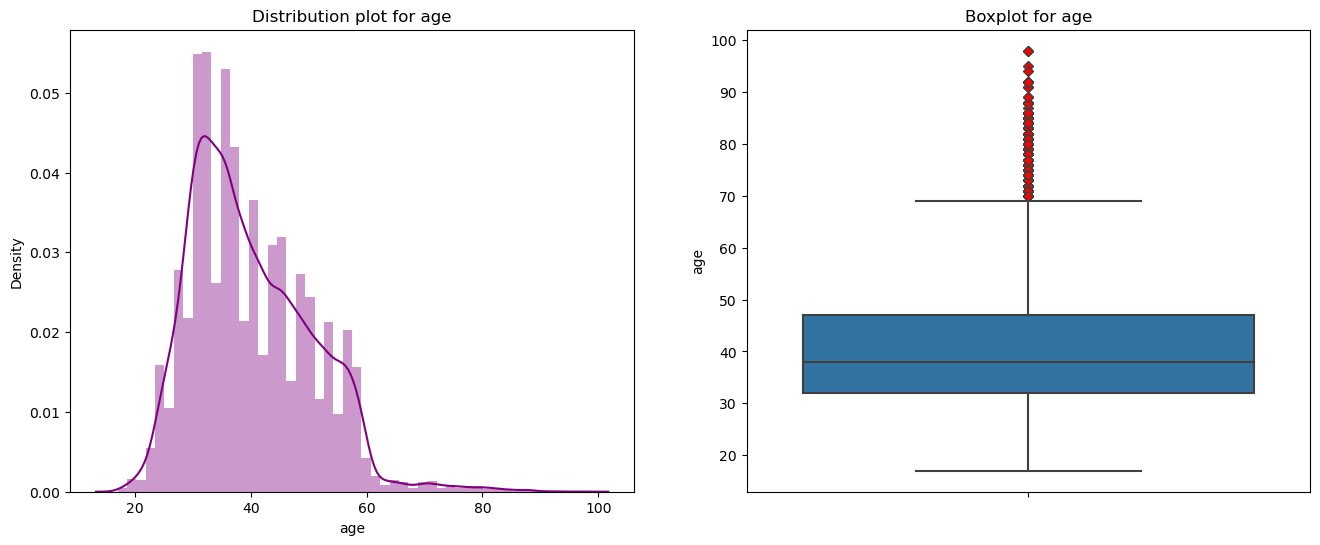

In [10]:
dist_box(data,'age')

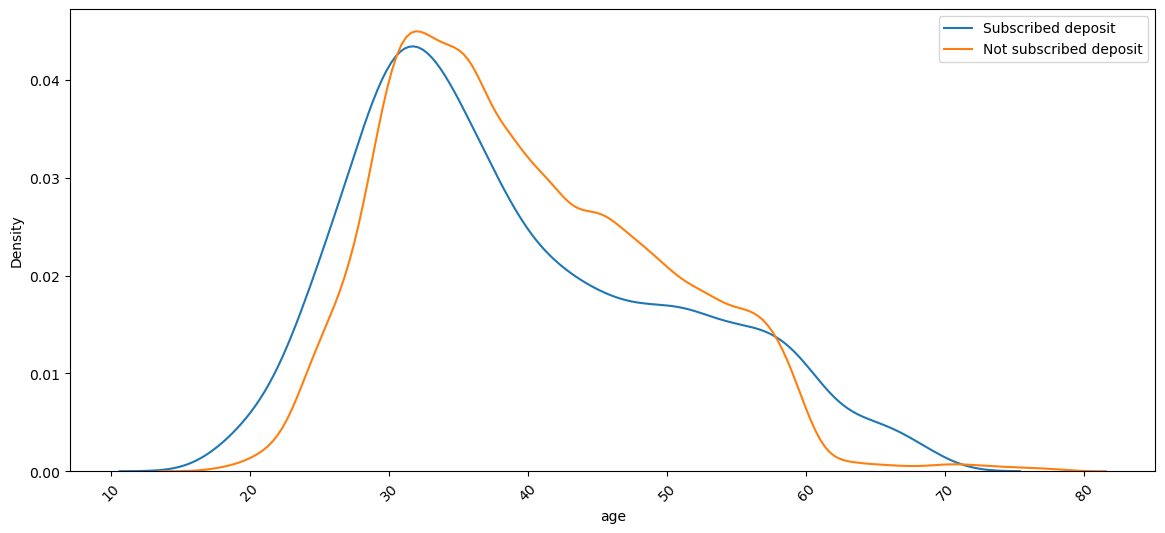

In [11]:
max_value_1 = outlier_range(data1,'age')
max_value_0 = outlier_range(data0,'age')
kde_no_outliers(data0, data1, max_value_1, max_value_0, 'age')

Тут розділення цієї змінної є трішки несиметричне, що показує нам, що клієнти 60+ були рідкісними випадками. І бачимо що віковий діапазон у людей які брати депозит, ширший, тобто як молоді клієнти біля 20 так і старші 60 частіше брали депозит ніж не брали.

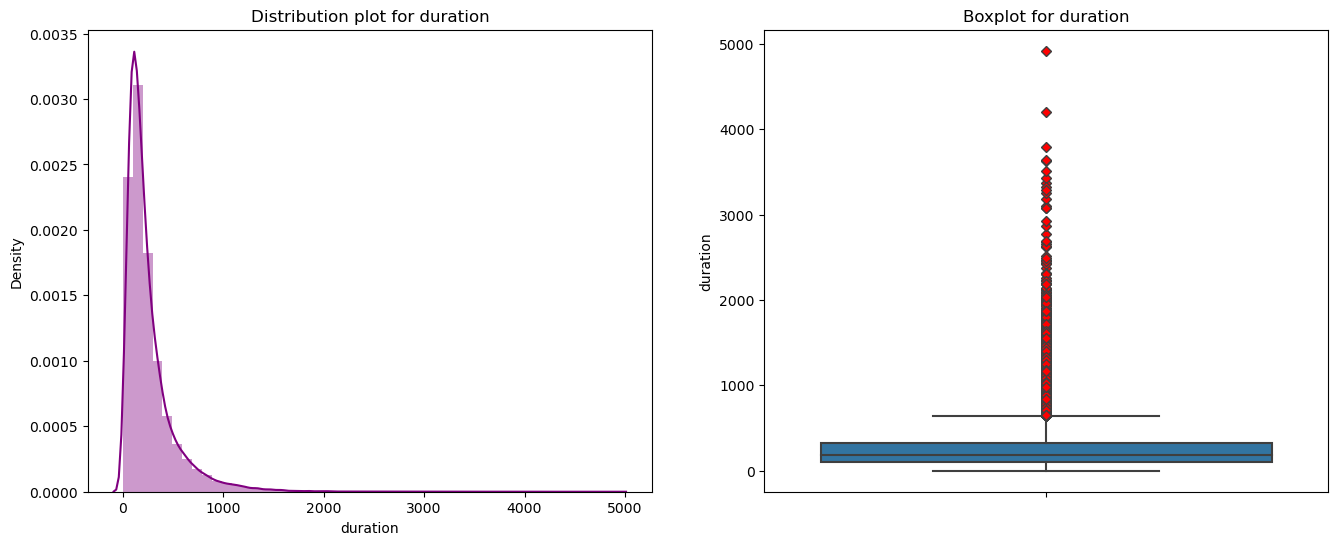

In [12]:
dist_box(data,'duration')

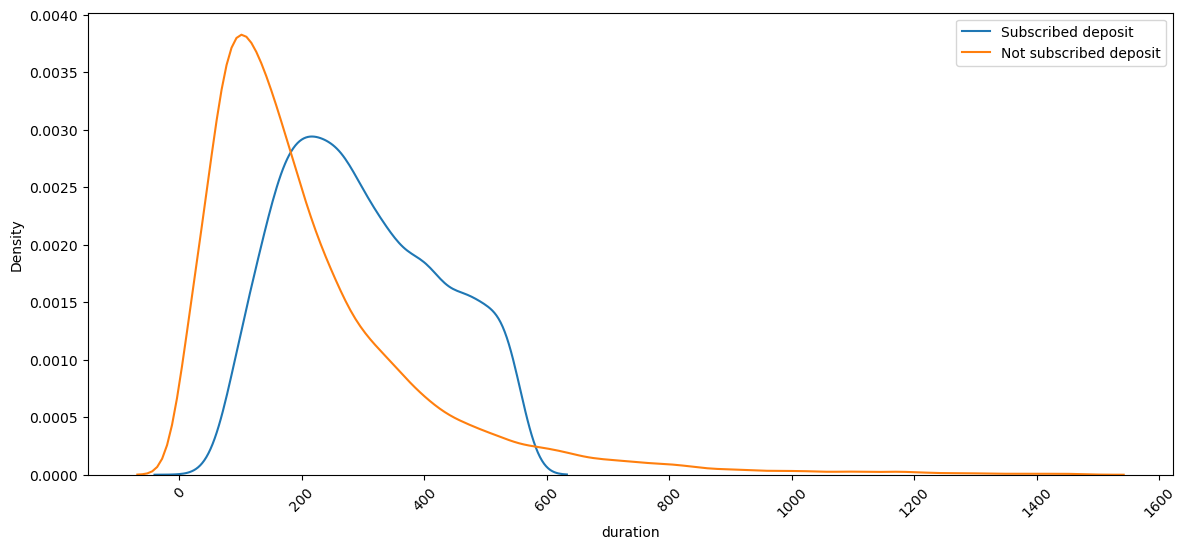

In [13]:
max_value_1 = outlier_range(data1,'duration')
max_value_0 = outlier_range(data0,'duration')
kde_no_outliers(data0, data1, max_value_1, max_value_0, 'duration')

In [14]:
data.drop(columns=['duration'], inplace=True)

Цю колонку я не використовуватиму при побудові моделі. 
Бо ми не знаємо наперед скільки триватиме розмова і по групуванню видно, що у загальної більшості учасників які підписали контракт про депозит, розмова тривала понад 100 секунд, але також якщо розмова тривала довше 600 секунд то клієнт зазвичай не підписував депозит.

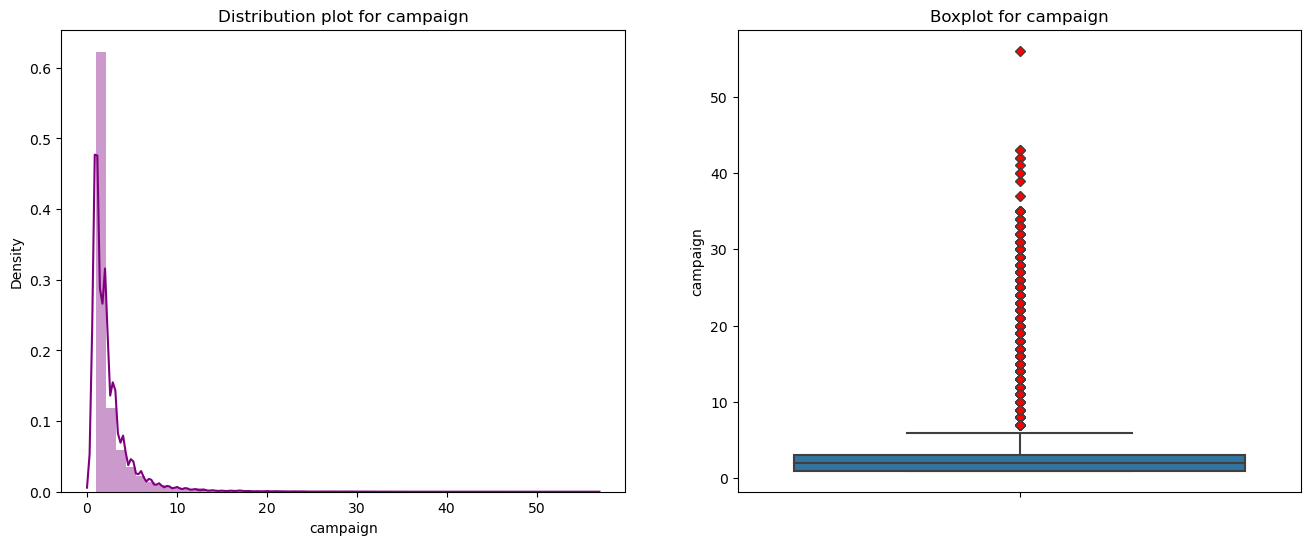

In [15]:
dist_box(data,'campaign')

In [16]:
data['campaign'] = np.log1p(data['campaign'])

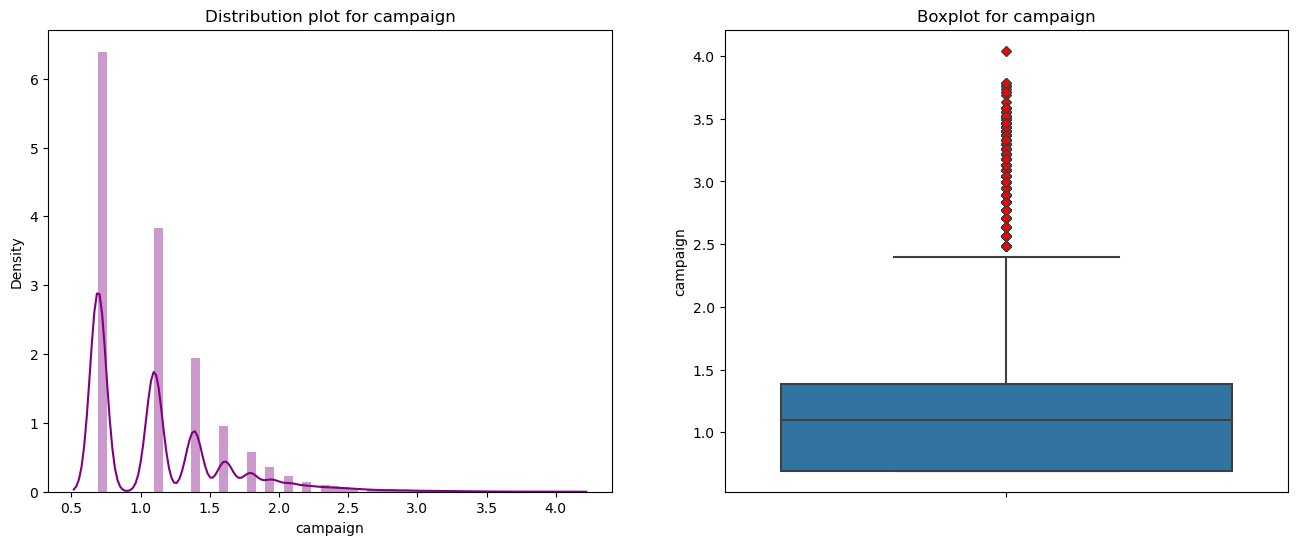

In [17]:
dist_box(data,'campaign')

In [18]:
pd.crosstab(data['campaign'], data['y'], normalize='index')

y,no,yes
campaign,,
0.693147,0.869627,0.130373
1.098612,0.885409,0.114591
1.386294,0.892509,0.107491
1.609438,0.906038,0.093962
1.791759,0.924953,0.075047
1.945910,0.923391,0.076609
2.079442,0.939587,0.060413
2.197225,0.957500,0.042500
2.302585,0.939929,0.060071


In [19]:
data['campaign'] = data['campaign'].clip(upper=2.5)

Тут я вирішила колонку campaign трансформувати логарифнічноютрансформацією для покращення масштабу даних, а також обрізала значення вищі 2,5, бо саме там з crosstab конверсія впала до нуля.

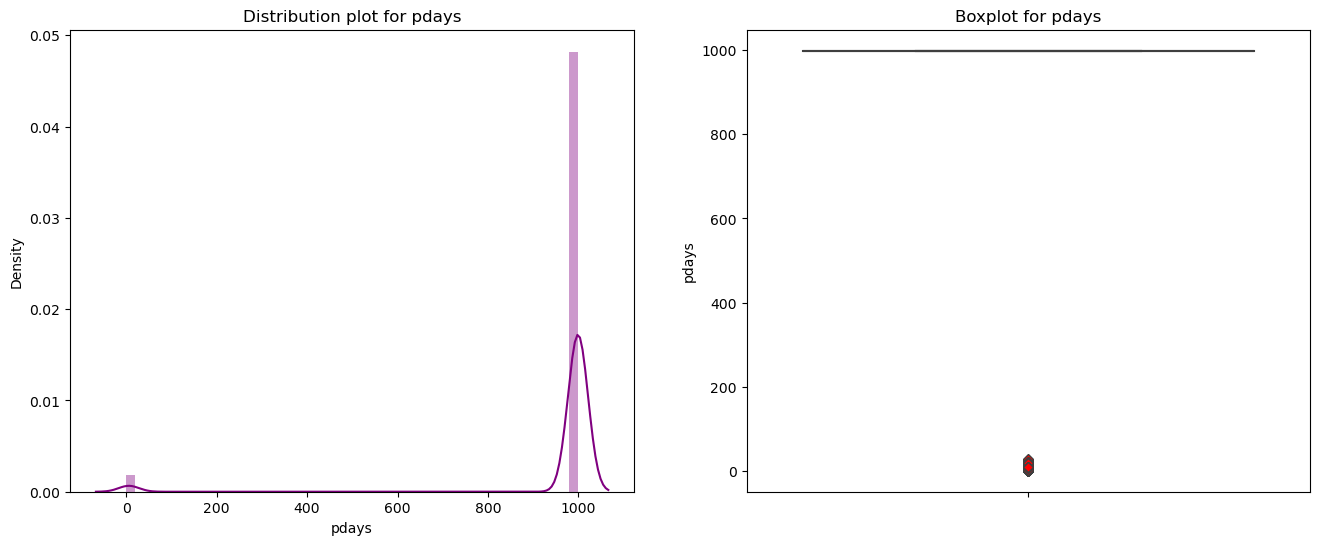

In [20]:
dist_box(data,'pdays')

In [21]:
data['pdays_was_contacted'] = (data['pdays'] != 999).astype(int)
data.drop(columns=['pdays'], inplace=True)

In [22]:
data['pdays_was_contacted'].value_counts()

0    39661
1     1515
Name: pdays_was_contacted, dtype: int64

Значення 999 є технічним маркером, а не реальним числом днів, але якраз більшість значень цієї фічі заповнені ним, тому ознаку pdays я замінила бінарною змінною, яка показує, чи був клієнт контактований раніше.

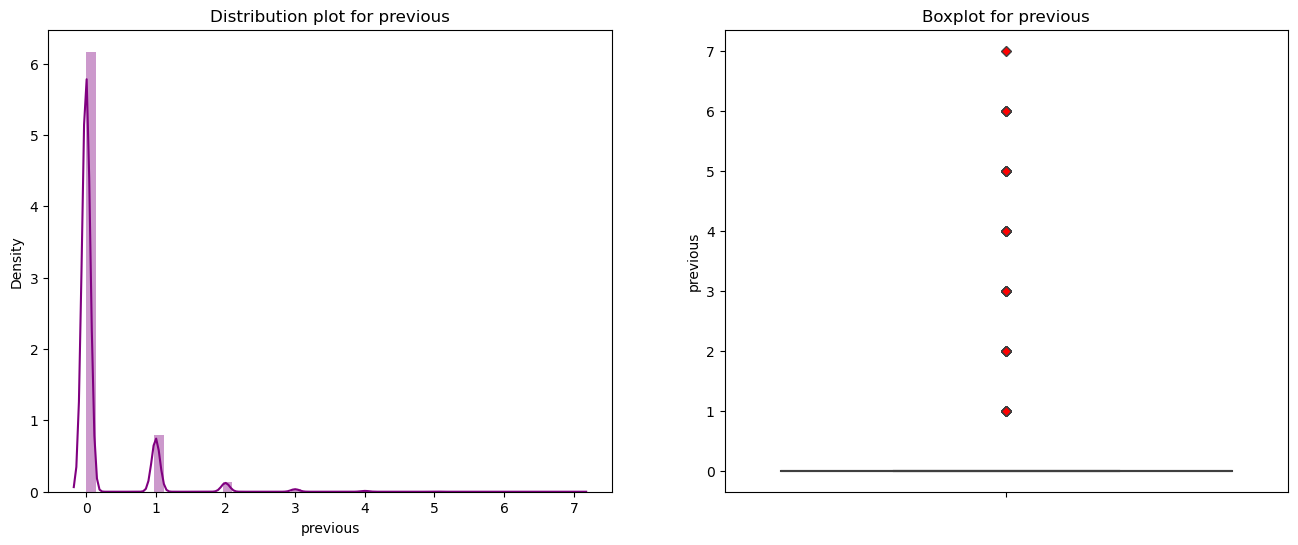

In [23]:
dist_box(data,'previous')

In [24]:
data['previous'].value_counts()

0    35551
1     4561
2      754
3      216
4       70
5       18
6        5
7        1
Name: previous, dtype: int64

In [25]:
pd.crosstab(data['previous'], data['y'], normalize='index')

y,no,yes
previous,,
0,0.911676,0.088324
1,0.787985,0.212015
2,0.535809,0.464191
3,0.407407,0.592593
4,0.457143,0.542857
5,0.277778,0.722222
6,0.400000,0.600000
7,1.000000,0.000000


In [26]:
data['had_previous_contact'] = (data['previous'] > 0).astype(int)

Із збільшенням кількості дзвінків попередньо до кампанії збільшується імовірність підписання депозиту. Я створила додаткову категоріальну змінну був контак чи не був, яку додам до регресного аналізу, бо бінарна ознака дає чіткий явний сигнал для лінійної границі

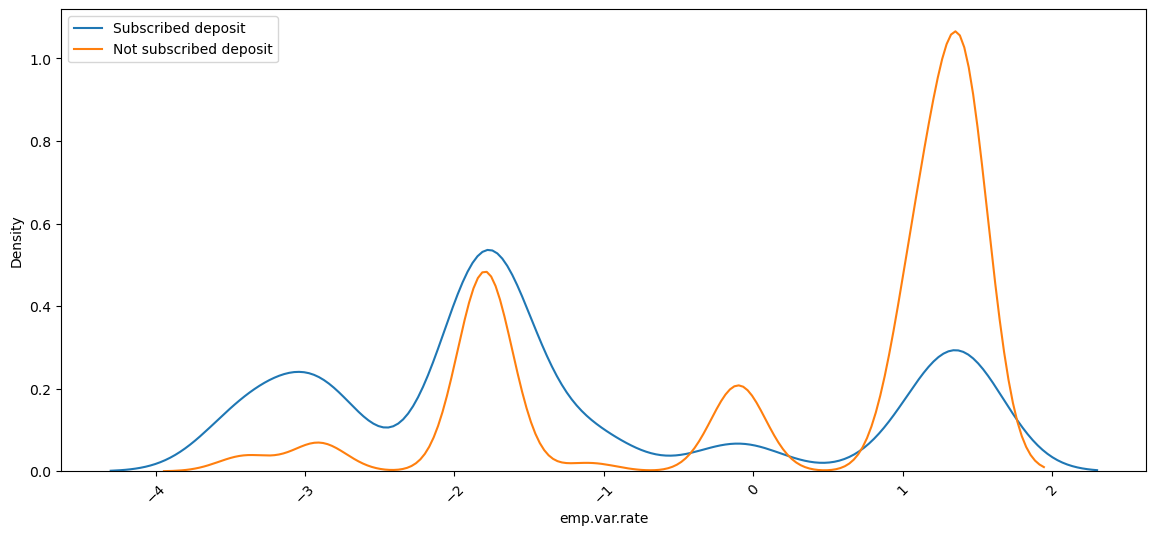

In [27]:
max_value_1 = outlier_range(data1,'emp.var.rate')
max_value_0 = outlier_range(data0,'emp.var.rate')
kde_no_outliers(data0, data1, max_value_1, max_value_0, 'emp.var.rate')

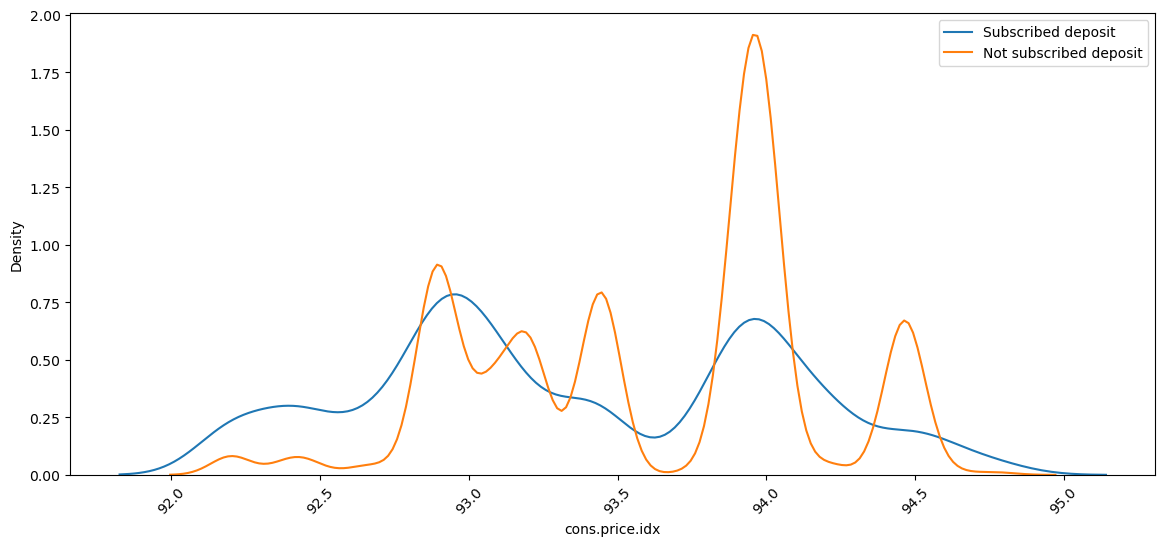

In [28]:
max_value_1 = outlier_range(data1,'cons.price.idx')
max_value_0 = outlier_range(data0,'cons.price.idx')
kde_no_outliers(data0, data1, max_value_1, max_value_0, 'cons.price.idx')

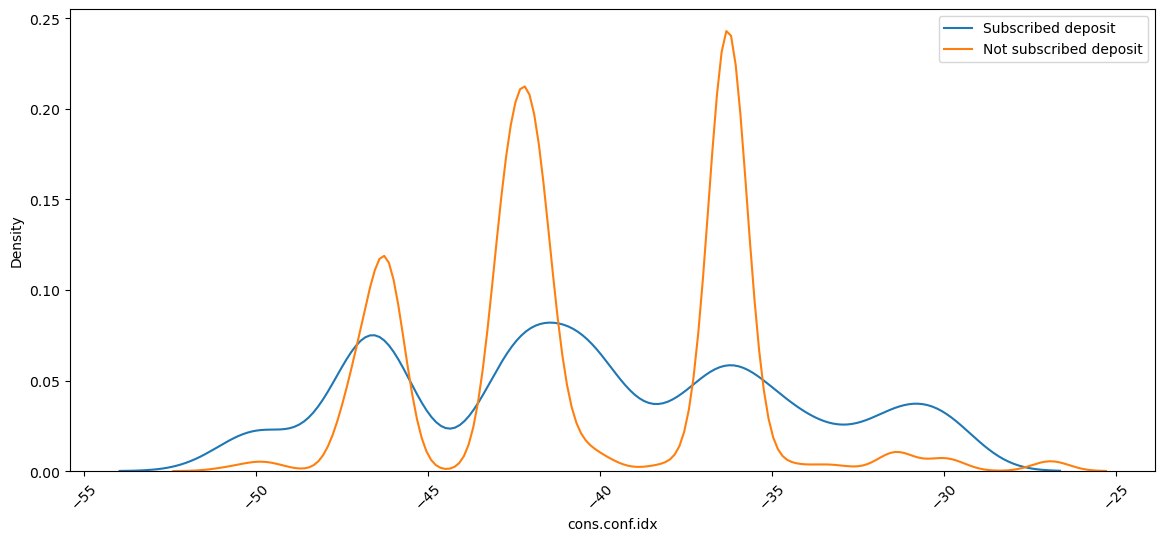

In [29]:
max_value_1 = outlier_range(data1,'cons.conf.idx')
max_value_0 = outlier_range(data0,'cons.conf.idx')
kde_no_outliers(data0, data1, max_value_1, max_value_0, 'cons.conf.idx')

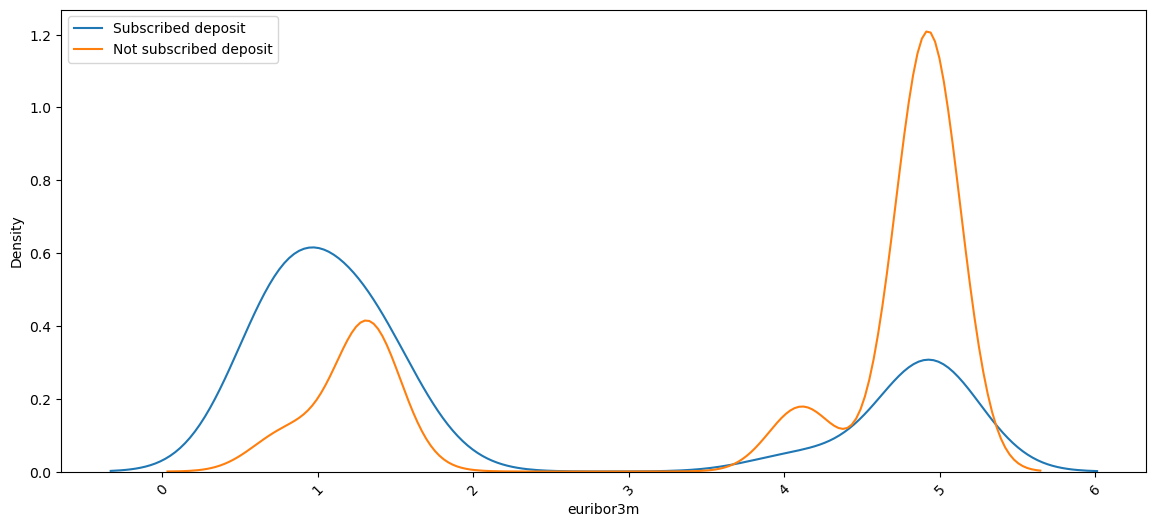

In [30]:
max_value_1 = outlier_range(data1,'euribor3m')
max_value_0 = outlier_range(data0,'euribor3m')
kde_no_outliers(data0, data1, max_value_1, max_value_0, 'euribor3m')

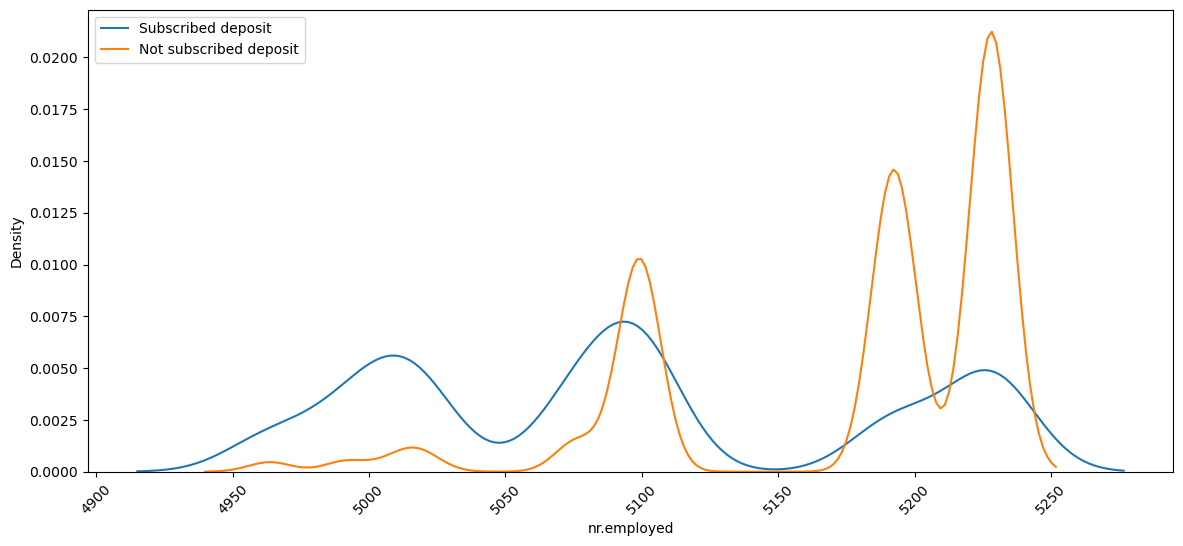

In [31]:
max_value_1 = outlier_range(data1,'nr.employed')
max_value_0 = outlier_range(data0,'nr.employed')
kde_no_outliers(data0, data1, max_value_1, max_value_0, 'nr.employed')

In [32]:
corr_data0 = data0.select_dtypes(include=["number"]).corr()
corr_data0[corr_data0 <= 0.99].unstack().sort_values(ascending = False).head(12)

emp.var.rate    euribor3m         0.975955
euribor3m       emp.var.rate      0.975955
nr.employed     euribor3m         0.947243
euribor3m       nr.employed       0.947243
emp.var.rate    nr.employed       0.921746
nr.employed     emp.var.rate      0.921746
cons.price.idx  emp.var.rate      0.797157
emp.var.rate    cons.price.idx    0.797157
cons.price.idx  euribor3m         0.730751
euribor3m       cons.price.idx    0.730751
nr.employed     cons.price.idx    0.593567
cons.price.idx  nr.employed       0.593567
dtype: float64

In [33]:
corr_data1 = data1.select_dtypes(include=["number"]).corr()
corr_data1[corr_data1 <= 0.99].unstack().sort_values(ascending = False).head(20)

euribor3m       emp.var.rate      0.926125
emp.var.rate    euribor3m         0.926125
euribor3m       nr.employed       0.922227
nr.employed     euribor3m         0.922227
                emp.var.rate      0.787679
emp.var.rate    nr.employed       0.787679
cons.price.idx  emp.var.rate      0.660248
emp.var.rate    cons.price.idx    0.660248
duration        emp.var.rate      0.502978
emp.var.rate    duration          0.502978
duration        euribor3m         0.499662
euribor3m       duration          0.499662
nr.employed     duration          0.481978
duration        nr.employed       0.481978
nr.employed     pdays             0.453373
pdays           nr.employed       0.453373
euribor3m       cons.price.idx    0.414507
cons.price.idx  euribor3m         0.414507
euribor3m       pdays             0.364626
pdays           euribor3m         0.364626
dtype: float64

Тут помітна кореляція між макроекономічними змінними, що могло б трохи мішати лінійній моделі, як логістична регресія, тому я порівняю результати моделі без корельованих змінних і з ними із регуляризацією

## Categorical features

In [34]:
data.describe(include='object')

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41176,41176,41176,41176,41176,41176,41176,41176,41176,41176,41176
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10419,24921,12164,32577,21571,33938,26135,13767,8618,35551,36537


In [35]:
data.job.value_counts(normalize = True)

admin.           0.253036
blue-collar      0.224718
technician       0.163663
services         0.096343
management       0.071012
retired          0.041723
entrepreneur     0.035360
self-employed    0.034510
housemaid        0.025743
unemployed       0.024626
student          0.021250
unknown          0.008014
Name: job, dtype: float64

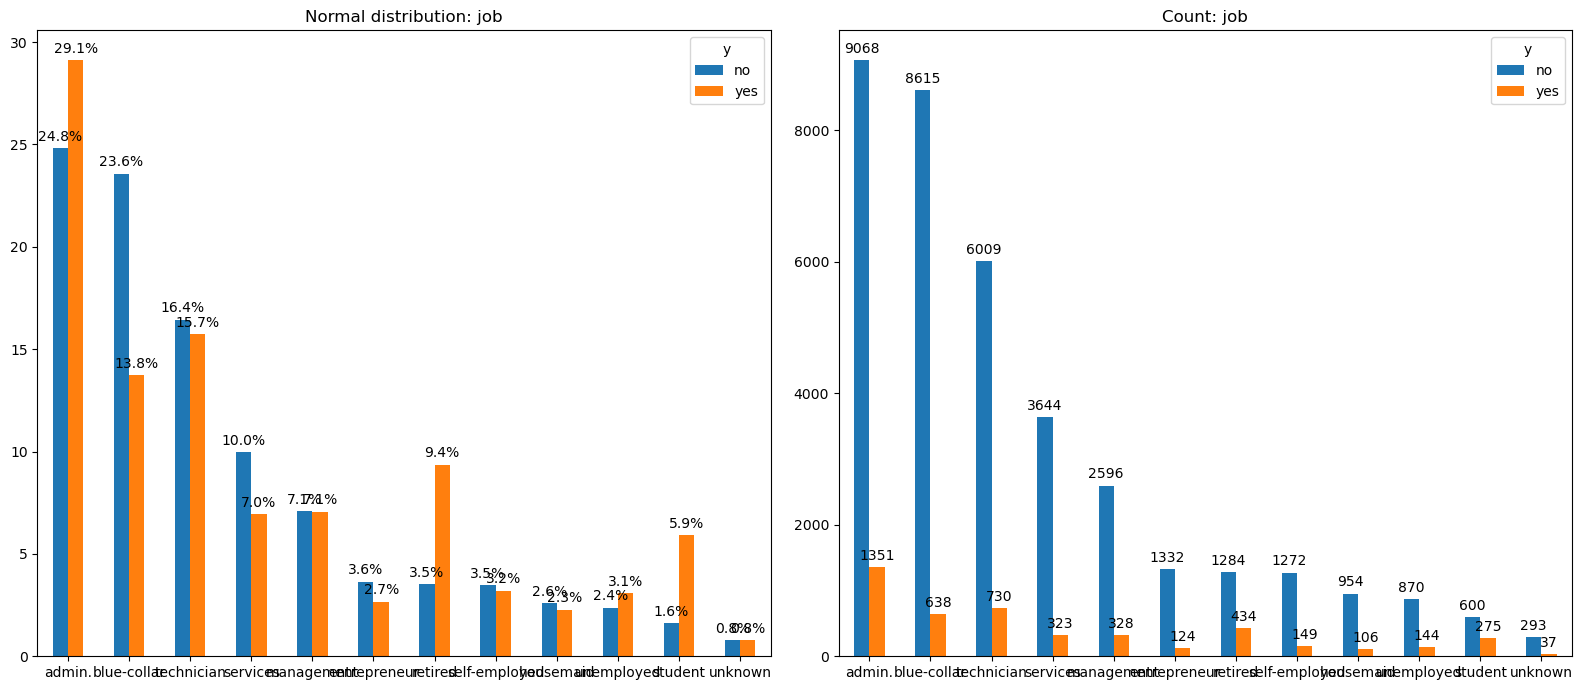

In [36]:
uni_cat_target_compare(data, 'job')

Тут можна спостерігати відмінність між тими хто відкрив депозит і хто ні. Суттєвої різниці як такої немає, але все ж частка студентів і entrepreneur більша серед тих, хто відкрив депозит, ніж серед тих, хто не відкрив, а частка blue-collar навпаки нижча.

In [37]:
data.marital.value_counts(normalize = True)

married     0.605231
single      0.280843
divorced    0.111983
unknown     0.001943
Name: marital, dtype: float64

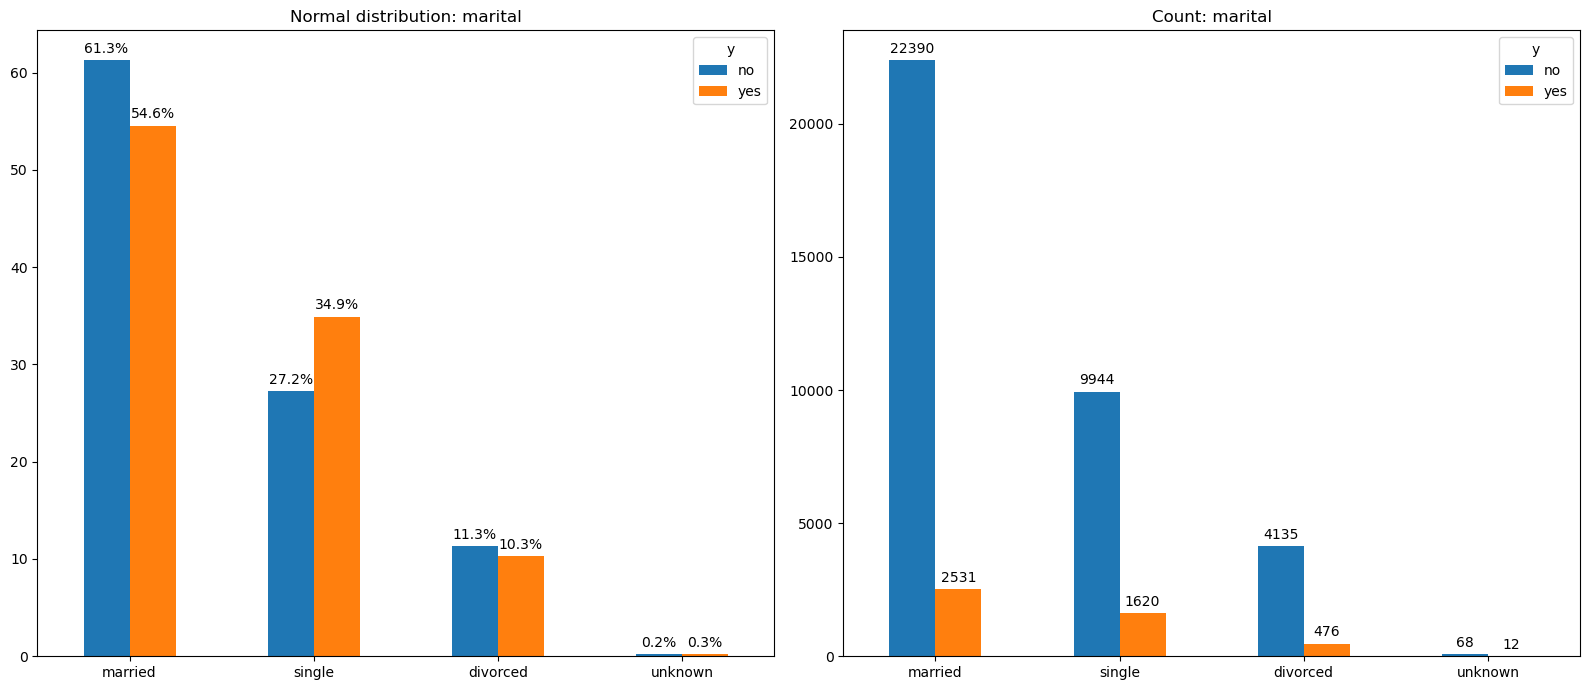

In [38]:
uni_cat_target_compare(data, 'marital')

Частка самотніх людей які беруть депозит більша ніж частка самотніх які не беруть депозит. А у одружених навпаки

In [39]:
data.education.value_counts(normalize = True)

university.degree      0.295415
high.school            0.231008
basic.9y               0.146809
professional.course    0.127259
basic.4y               0.101418
basic.6y               0.055639
unknown                0.042015
illiterate             0.000437
Name: education, dtype: float64

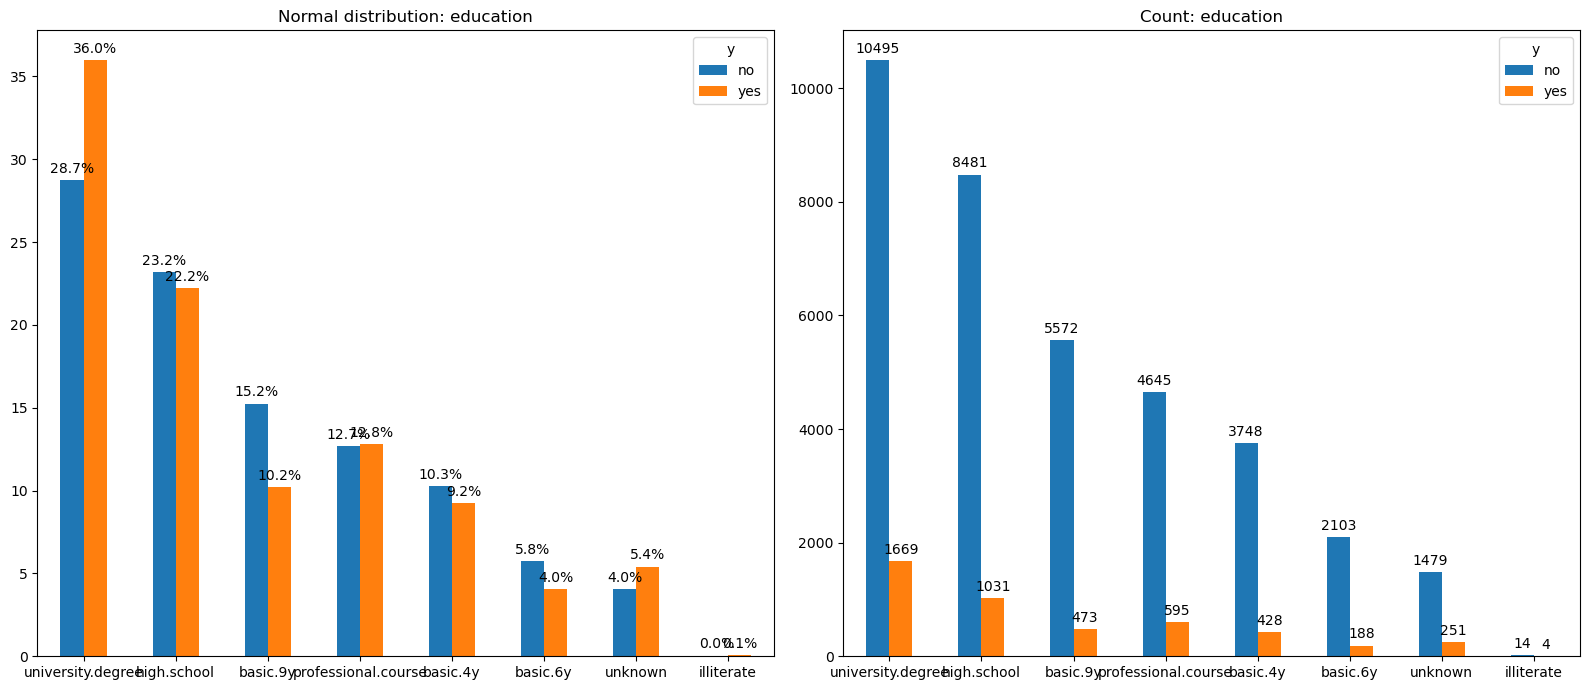

In [40]:
uni_cat_target_compare(data, 'education')

Частка людей із закінченим університетом більша серед тих, хто відкрив депозит, ніж серед тих, хто не відкрив

In [41]:
data.default.value_counts()

no         32577
unknown     8596
yes            3
Name: default, dtype: int64

In [42]:
data.drop(columns=['default'], inplace=True)

Ознака default має дуже незбалансований розподіл категорій: клас yes трапляється вкрай рідко, а велика частка значень припадає на unknown. Через це ознака була виключена як потенційно малокорисна і нестабільна для моделювання.

In [43]:
data.housing.value_counts(normalize = True)

yes        0.523873
no         0.452084
unknown    0.024043
Name: housing, dtype: float64

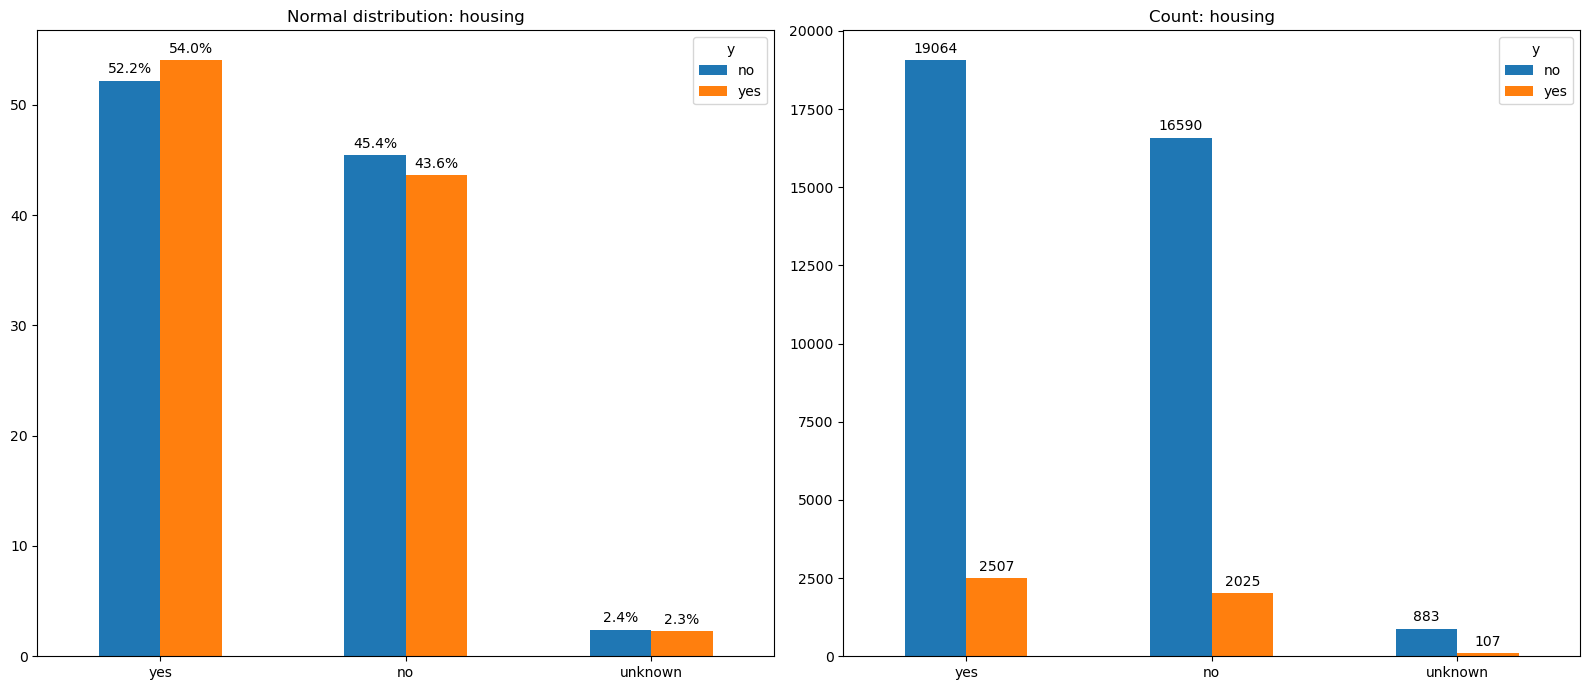

In [44]:
uni_cat_target_compare(data, 'housing')

In [45]:
data.loan.value_counts(normalize = True)

no         0.824218
yes        0.151739
unknown    0.024043
Name: loan, dtype: float64

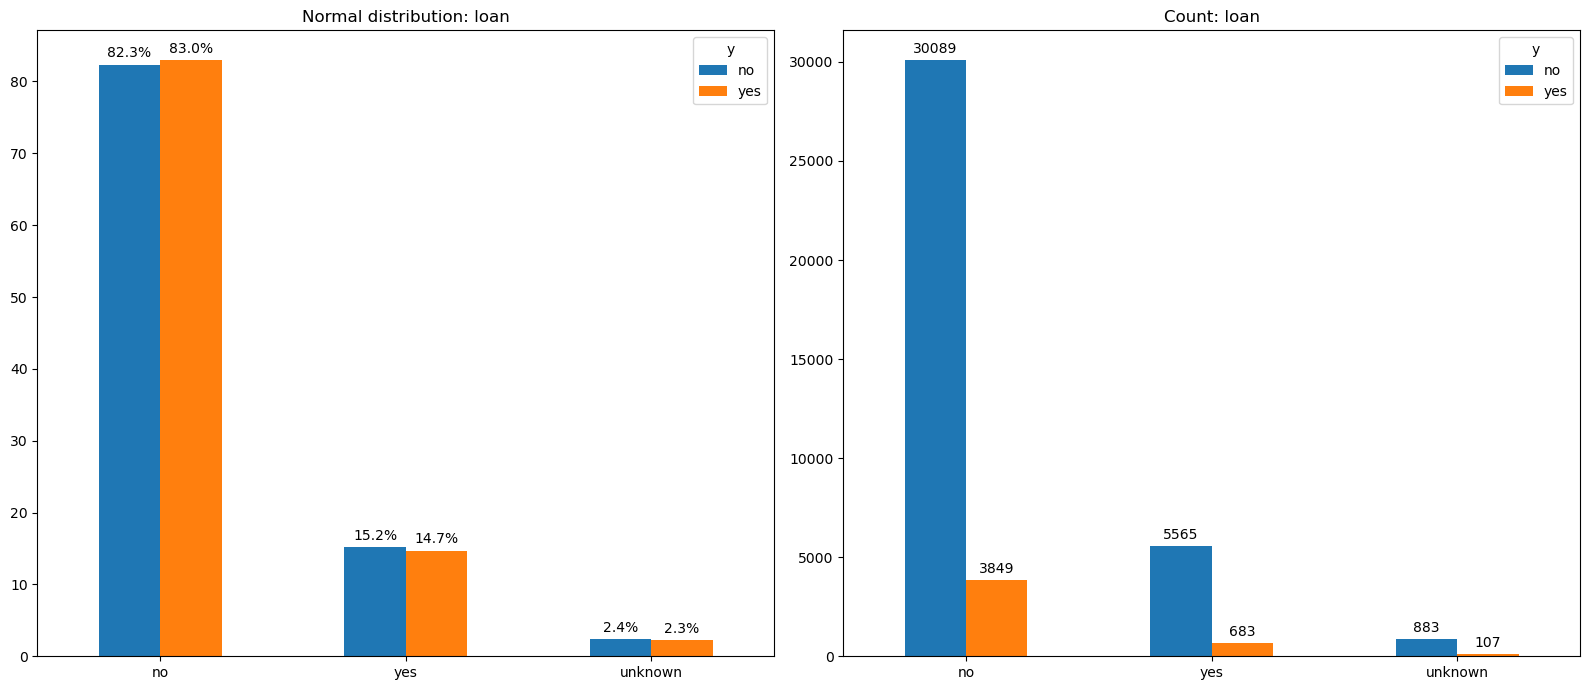

In [46]:
uni_cat_target_compare(data, 'loan')

In [47]:
data.contact.value_counts()

cellular     26135
telephone    15041
Name: contact, dtype: int64

Тут у часток категорій які мають кредити і не мають немає різниці, що означає, що ця змінна скоріш за все не сильно матиме вплив на те візьме людина депозит чи ні. Але я залишу ці змінні, нехай модель сама оцінить важливість.

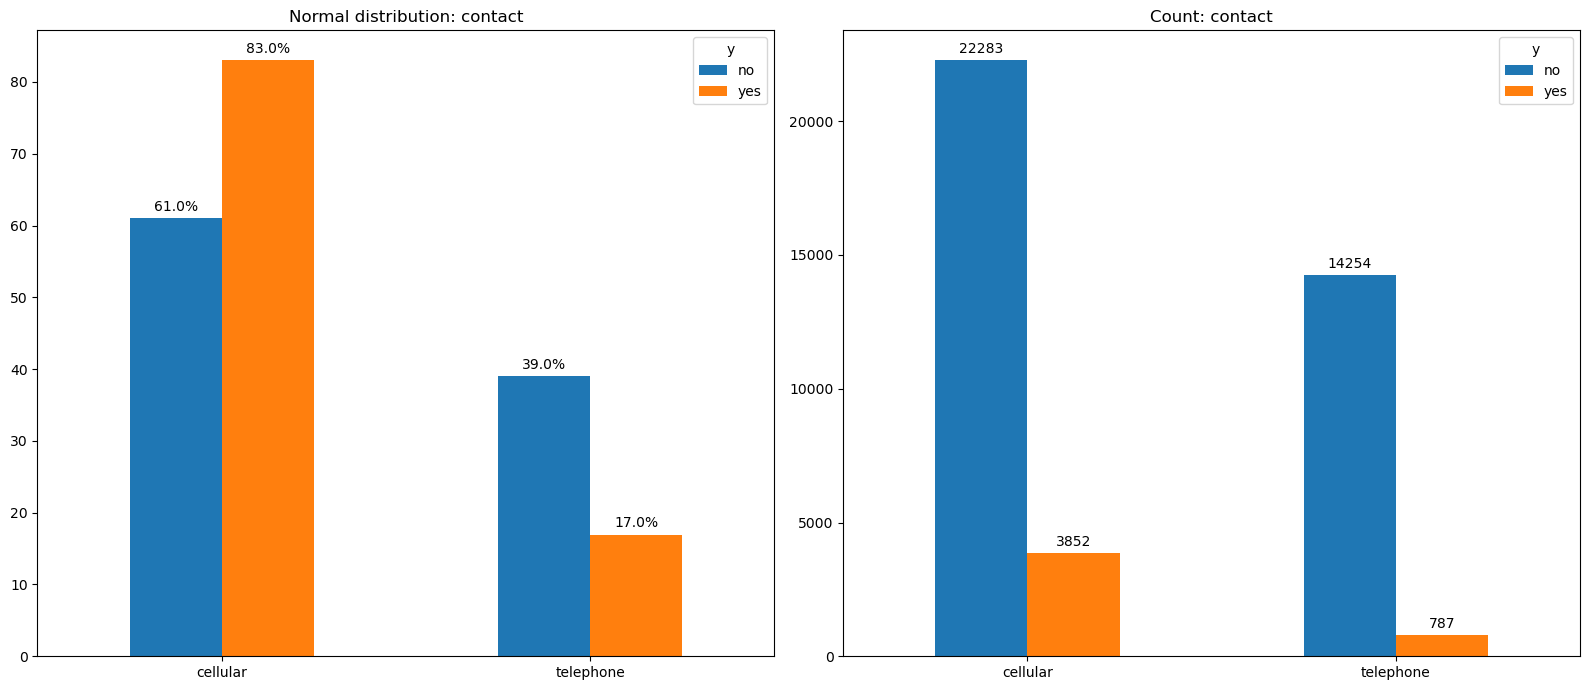

In [48]:
uni_cat_target_compare(data, 'contact')

Частка людей які контактували cellular більша серед тих, хто відкрив депозит, ніж серед тих, хто не відкрив

In [49]:
data.month.value_counts()

may    13767
jul     7169
aug     6176
jun     5318
nov     4100
apr     2631
oct      717
sep      570
mar      546
dec      182
Name: month, dtype: int64

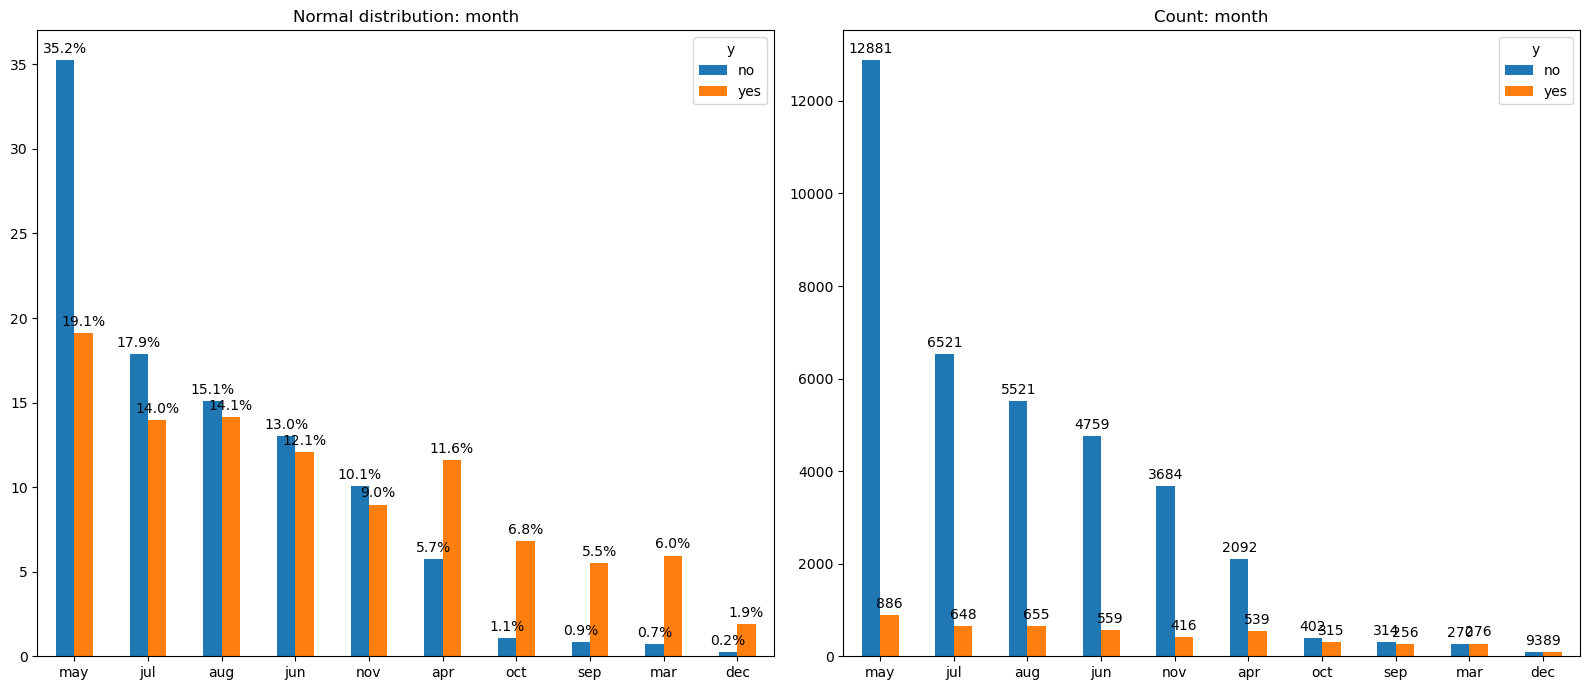

In [50]:
uni_cat_target_compare(data, 'month')

Частка людей з якими контактували в квітні, жовтні, вересні, березні та грудні більша серед тих, хто відкрив депозит, ніж серед тих, хто не відкрив. А також у травні частка людей які не підписали депозит вдвічі більша за частку серед тих які не підписали

In [51]:
data.day_of_week.value_counts()

thu    8618
mon    8512
wed    8134
tue    8086
fri    7826
Name: day_of_week, dtype: int64

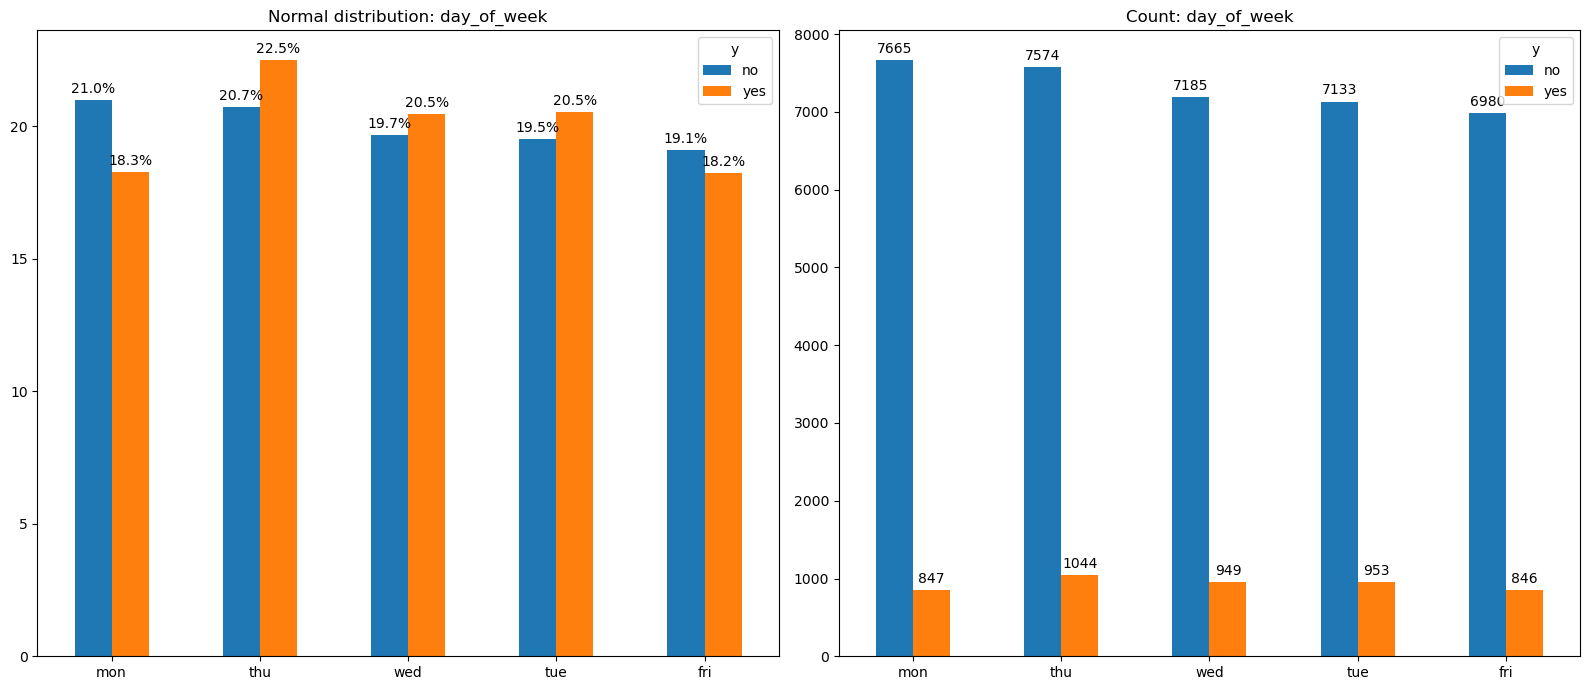

In [52]:
uni_cat_target_compare(data, 'day_of_week')

In [53]:
data.poutcome.value_counts()

nonexistent    35551
failure         4252
success         1373
Name: poutcome, dtype: int64

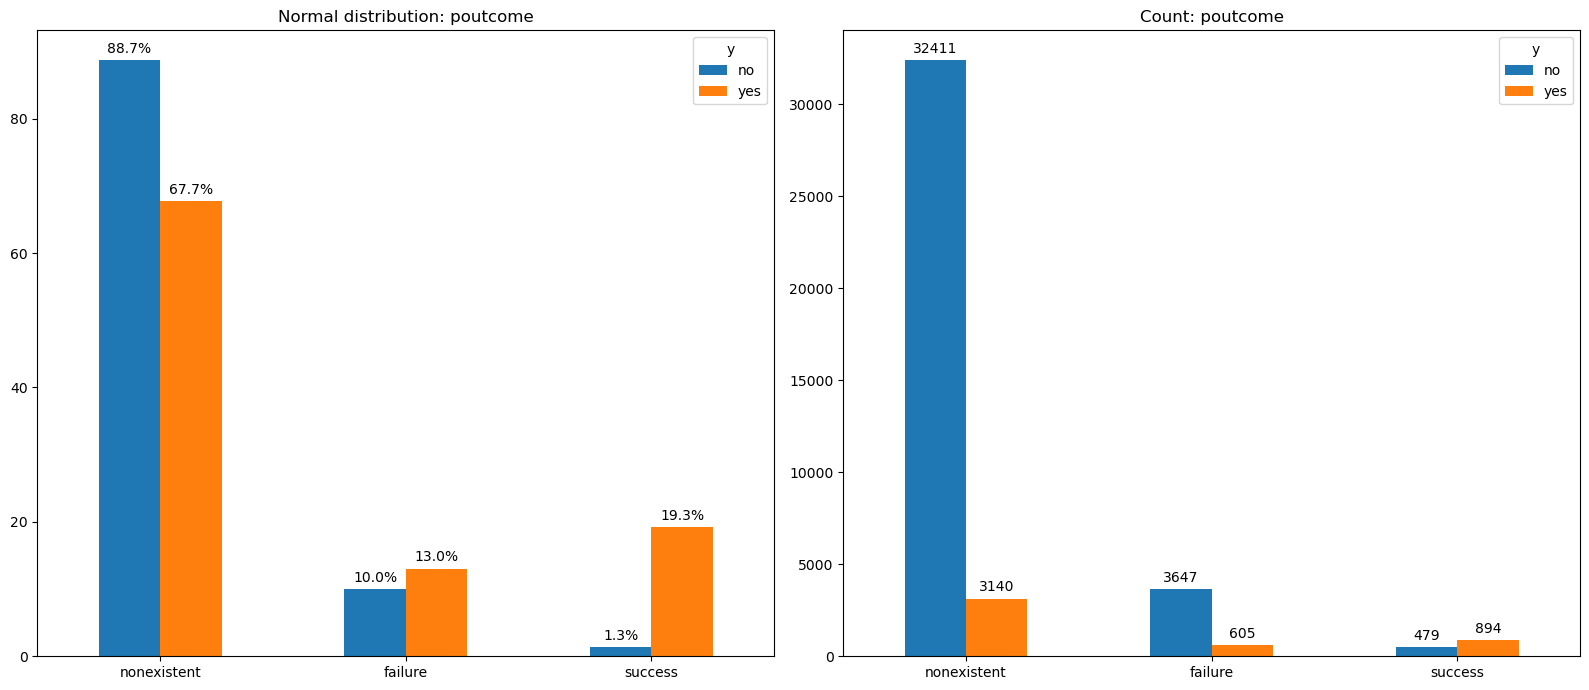

In [54]:
uni_cat_target_compare(data, 'poutcome')

Ну і тут звісно трішки очікувано, часка клієнтів з якими контактували попередні кампанії і завершилиши успішно більша серед тих, хто відкрив депозит, ніж серед тих, хто не відкрив

## Hypotheses

Якщо відштовхуватися від EDA, можна сформувати такі гіпотези:

1. Клієнти до 25 і після 60 частіше підпишуть депозит ніж не підпишуть
2. чим більше клієнт від кампанії дзвінків отримує тим менша ймовірніть підписання депозиту
3. якщо пристуній контакт з поперденьою кампанією, шанси на підписання депозиту з цим клієнтом вищі
4. від'ємний темп зміни зайнятості - клієнт швидше підпише депозит ніж не підпише
5. ставка Euribor нижча 3 - теж піднімає ймовірність успіху
6. рівень освіти також впливає трохи на успіх на підписання депозиту
7. шанс підписати депозит з клієнтом з яким контактували за Cellular вищий ніж якщо інша техніка
8. Місяць у якому з клієнтом контактували, теж має вплив
9. ну і звісно високий вплив на результат має також результат після контактування у попередній компанії: успіх у попередній значно повищує успіх у поточній

## Models to use:
Моделі які я вирішила використати:
1. Логістична регресія - базова модель для бінарної коасифікації
2. Knn класифікація - непараметрична модель, яка не робить жодних припущень про розподіл даних і може вловлювати локальні патерни
3. Дерево прийняття рішень - нелінійна складніша модель яка при цьому залишається інтерпретованою
4. XGBoosting - градієнтний бустинг, який зазвичай показує найкращу якість на табличних даних

# Preprocessing and models

In [55]:
data["y"] = data["y"].map({"no": 0, "yes": 1})
TARGET = "y"
 
binary_cols = ["pdays_was_contacted"]
binary_cols_ = binary_cols + ["had_previous_contact"] # для логрегресії і кнн я вирішила ще додати бінарну колонку had_previous_contact 
                                                      # для tree/xgb бінарна ознака надлишкова бо вони самі розіб'ють previous на порогах
    
numeric_cols = [col for col in data.select_dtypes(include="number").columns if col not in binary_cols + [TARGET] + ["had_previous_contact"]]

 
categorical_cols = data.select_dtypes(include="object").columns.tolist()

for col in categorical_cols:
    data[col] = data[col].replace('unknown', np.nan) # щоб при OneHotEncoder не створювалася окрема колонка із unkown                                                    

print("Numeric cols: ", len(numeric_cols), numeric_cols)
print("Binary cols: ", len(binary_cols_), binary_cols_)
print("Categorical cols:", len(categorical_cols), categorical_cols)

Numeric cols:  8 ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Binary cols:  2 ['pdays_was_contacted', 'had_previous_contact']
Categorical cols: 9 ['job', 'marital', 'education', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [56]:
X = data.drop(columns=[TARGET])
y = data[TARGET]
 
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
 
print(f"Train: {X_train.shape[0]}  |  Val: {X_val.shape[0]}")
print(f"Баланс класів (train): {y_train.value_counts(normalize=True).round(3).to_dict()}")

Train: 32940  |  Val: 8236
Баланс класів (train): {0: 0.887, 1: 0.113}


In [57]:
preprocessor_scale = ColumnTransformer([      #  для лог регресії
    ("num", StandardScaler(), numeric_cols),
    ("bin", "passthrough", binary_cols_),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
])

preprocessor_knn_pca = Pipeline([            # для кнн з пца редукцією фічєй
    ("prep", preprocessor_scale),
    ("pca", PCA(n_components=25, random_state=42))
])

preprocessor_noscale = ColumnTransformer([   # для дерев і для бустингу, бо не потрібно масштабувати,
    ("num", "passthrough", numeric_cols),    # бо модель сама може і навіть краще справиться з цим
    ("bin", "passthrough", binary_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
])

In [58]:
cols_logreg_knn = numeric_cols + binary_cols_ + categorical_cols
cols_ = numeric_cols + binary_cols + categorical_cols
 
X_train_logreg_knn = X_train[cols_logreg_knn]
X_val_logreg_knn = X_val[cols_logreg_knn]
 
X_train_ = X_train[cols_]
X_val_ = X_val[cols_]
 
X_train_logregg = preprocessor_scale.fit_transform(X_train_logreg_knn)
X_val_logregg = preprocessor_scale.transform(X_val_logreg_knn)

X_train_knn = preprocessor_knn_pca.fit_transform(X_train_logreg_knn)
X_val_knn = preprocessor_knn_pca.transform(X_val_logreg_knn)
 
X_train_noscale = preprocessor_noscale.fit_transform(X_train_)
X_val_noscale = preprocessor_noscale.transform(X_val_)
 
print("Scaled shape  :", X_train_logregg.shape)
print("Scaled shape  :", X_train_knn.shape)
print("Noscale shape :", X_train_noscale.shape)

Scaled shape  : (32940, 60)
Scaled shape  : (32940, 25)
Noscale shape : (32940, 59)


In [59]:
def evaluate_model(model, X_train, y_train, X_val, y_val, model_name="Model", threshold=0.5, fit_model=True):

    if fit_model:
        model.fit(X_train, y_train)
 
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_val_proba   = model.predict_proba(X_val)[:, 1]
 
    y_train_pred = (y_train_proba >= threshold).astype(int)
    y_val_pred   = (y_val_proba   >= threshold).astype(int)
 
    results = pd.DataFrame({
        "dataset":   ["train", "validation"],
        "threshold": [threshold, threshold],
        "accuracy":  [accuracy_score(y_train, y_train_pred),
                      accuracy_score(y_val,   y_val_pred)],
        "precision": [precision_score(y_train, y_train_pred, zero_division=0),
                      precision_score(y_val,   y_val_pred,   zero_division=0)],
        "recall":    [recall_score(y_train, y_train_pred, zero_division=0),
                      recall_score(y_val,   y_val_pred,   zero_division=0)],
        "f1":        [f1_score(y_train, y_train_pred, zero_division=0),
                      f1_score(y_val,   y_val_pred,   zero_division=0)],
        "roc_auc":   [roc_auc_score(y_train, y_train_proba),
                      roc_auc_score(y_val,   y_val_proba)],
    })
 
    results.insert(0, "model", model_name)
    return results.round(4)
 

In [60]:
all_results = [] 

Коли я прибрала корельовані змінні для логістичної регресії— модель навіть трішки погіршилась, тому залишила всі з регуляризацією

## Logistic regression

In [61]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


logreg_params = {
    "penalty":      ["l1", "l2", "elasticnet"],
    "C":            [0.001, 0.01, 0.1, 1, 5, 10, 50, 100],
    "l1_ratio":     [0.1, 0.3, 0.5, 0.7, 0.9],
    "class_weight": [None, "balanced"],
}

logreg_random = RandomizedSearchCV(
    LogisticRegression(max_iter=5000, solver="saga", random_state=42),
    logreg_params,
    n_iter=100, scoring="f1",
    cv=cv, random_state=42, n_jobs=-1, verbose=1
)
logreg_random.fit(X_train_logregg, y_train)

print("Best params:", logreg_random.best_params_)
print("Best CV F1 :", round(logreg_random.best_score_, 4))

best_model = logreg_random.best_estimator_
y_val_proba = best_model.predict_proba(X_val_logregg)[:, 1]

thresholds = np.arange(0.1, 0.91, 0.01)

best_threshold = 0.5
best_f1 = 0

for t in thresholds:
    y_val_pred = (y_val_proba >= t).astype(int)
    f1 = f1_score(y_val, y_val_pred)
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t


logreg_results = evaluate_model(
    logreg_random.best_estimator_,
    X_train_logregg, y_train,
    X_val_logregg,   y_val,
    model_name="Logistic Regression",
    threshold=best_threshold,
    fit_model=False,
)
all_results.append(logreg_results)
logreg_results

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best params: {'penalty': 'elasticnet', 'l1_ratio': 0.5, 'class_weight': 'balanced', 'C': 100}
Best CV F1 : 0.4514


,model,dataset,threshold,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,train,0.65,0.8644,0.4238,0.5664,0.4848,0.7945
1,Logistic Regression,validation,0.65,0.8701,0.4428,0.5927,0.5069,0.7996


## Knn classification

In [62]:
knn_params = {
    "n_neighbors": list(range(50, 101, 5)),  
    "metric": ["euclidean", "manhattan"],
}
 
knn_random = RandomizedSearchCV(
    KNeighborsClassifier(),
    knn_params,
    n_iter=25, scoring="f1",
    cv=cv, random_state=42, n_jobs=-1, verbose=1,
)
knn_random.fit(X_train_knn, y_train)
 
print("Best params:", knn_random.best_params_)
print("Best CV F1 :", round(knn_random.best_score_, 4))
 
best_model = knn_random.best_estimator_
y_val_proba = best_model.predict_proba(X_val_knn)[:, 1]

thresholds = np.arange(0.1, 0.91, 0.01)

best_threshold = 0.5
best_f1 = 0

for t in thresholds:
    y_val_pred = (y_val_proba >= t).astype(int)
    f1 = f1_score(y_val, y_val_pred)
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t


knn_results = evaluate_model(
    knn_random.best_estimator_,
    X_train_knn, y_train,
    X_val_knn,   y_val,
    model_name="kNN",
    threshold=best_threshold,
    fit_model=False,
)
all_results.append(knn_results)
knn_results  

C:\Users\Admin\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 22 is smaller than n_iter=25. Running 22 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 22 candidates, totalling 110 fits
Best params: {'n_neighbors': 55, 'metric': 'manhattan'}
Best CV F1 : 0.3212


,model,dataset,threshold,accuracy,precision,recall,f1,roc_auc
0,kNN,train,0.21,0.8707,0.4406,0.5462,0.4877,0.8242
1,kNN,validation,0.21,0.8765,0.4606,0.5603,0.5056,0.7889


## Decision tree

In [63]:
tree_params = {
    "max_depth": [3, 4, 5, 6, 7, 8],
    "min_samples_leaf": [10, 20, 30, 50, 75, 100],
    "min_samples_split": [20, 30, 50, 75, 100, 150],
    "criterion": ["gini", "entropy"],
    "class_weight": [None, "balanced"],
    "ccp_alpha": [0.0, 0.0001, 0.0005, 0.001, 0.002, 0.005],
}

tree_random = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    tree_params,
    n_iter=120, scoring="f1",
    cv=cv, random_state=42, n_jobs=-1, verbose=1,
)
tree_random.fit(X_train_noscale, y_train)
 
print("Best params:", tree_random.best_params_)
print("Best CV F1 :", round(tree_random.best_score_, 4))
 
best_model = tree_random.best_estimator_
y_val_proba = best_model.predict_proba(X_val_noscale)[:, 1]

thresholds = np.arange(0.1, 0.91, 0.01)

best_threshold = 0.5
best_f1 = 0

for t in thresholds:
    y_val_pred = (y_val_proba >= t).astype(int)
    f1 = f1_score(y_val, y_val_pred)
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t


tree_results = evaluate_model(
    tree_random.best_estimator_,
    X_train_noscale, y_train,
    X_val_noscale,   y_val,
    model_name="Decision Tree",
    threshold=best_threshold,
    fit_model=False,
)
all_results.append(tree_results)
tree_results      

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best params: {'min_samples_split': 20, 'min_samples_leaf': 10, 'max_depth': 6, 'criterion': 'entropy', 'class_weight': 'balanced', 'ccp_alpha': 0.0001}
Best CV F1 : 0.4804


,model,dataset,threshold,accuracy,precision,recall,f1,roc_auc
0,Decision Tree,train,0.48,0.8703,0.4418,0.5750,0.4997,0.7905
1,Decision Tree,validation,0.48,0.8763,0.4626,0.6056,0.5245,0.8008


## XGBoosting

In [64]:
counts = y_train.value_counts()
print("scale_pos_weight =", round(counts[0] / counts[1], 2))

scale_pos_weight = 7.88


In [65]:
xgb_params = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1, 0.15],
    "subsample": [0.6, 0.7, 0.8, 0.9],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.2],
    "reg_alpha": [0, 0.1, 1.0],
    "reg_lambda": [1.0, 2.0, 5.0],
}
 
xgb_random = RandomizedSearchCV(
    XGBClassifier(
        eval_metric="logloss",
        scale_pos_weight=7.88,  
        random_state=42,
        n_jobs=-1,
    ),
    xgb_params,
    n_iter=160, scoring="f1",
    cv=cv, random_state=42, n_jobs=-1, verbose=1,
)
xgb_random.fit(X_train_noscale, y_train)
 
print("Best params:", xgb_random.best_params_)
print("Best CV F1 :", round(xgb_random.best_score_, 4))
 
    
best_model = xgb_random.best_estimator_
y_val_proba = best_model.predict_proba(X_val_noscale)[:, 1]

thresholds = np.arange(0.1, 0.91, 0.01)

best_threshold = 0.5
best_f1 = 0

for t in thresholds:
    y_val_pred = (y_val_proba >= t).astype(int)
    f1 = f1_score(y_val, y_val_pred)
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t


xgb_random_results = evaluate_model(
    xgb_random.best_estimator_,
    X_train_noscale, y_train,
    X_val_noscale,   y_val,
    model_name="XGBoost (RandomizedSearch)",
    threshold=best_threshold,
    fit_model=False,
)
all_results.append(xgb_random_results)
xgb_random_results      

Fitting 5 folds for each of 160 candidates, totalling 800 fits
Best params: {'subsample': 0.7, 'reg_lambda': 2.0, 'reg_alpha': 1.0, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.8}
Best CV F1 : 0.4741


,model,dataset,threshold,accuracy,precision,recall,f1,roc_auc
0,XGBoost (RandomizedSearch),train,0.58,0.8743,0.4545,0.5794,0.5094,0.8161
1,XGBoost (RandomizedSearch),validation,0.58,0.8804,0.4757,0.6002,0.5307,0.8133


In [66]:
def xgb_objective(params):
    params["max_depth"]        = int(params["max_depth"])
    params["min_child_weight"] = int(params["min_child_weight"])
    params["n_estimators"]     = int(params["n_estimators"])
    
    model = XGBClassifier(
        **params,
        scale_pos_weight=7.88,  # враховую незбалансованість класів
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
    )
    scores = cross_val_score(
        model, X_train_noscale, y_train,
        scoring="f1", cv=cv,
    )
    return {"loss": -scores.mean(), "status": STATUS_OK}

xgb_space = {
    "n_estimators":     hp.quniform("n_estimators",     100, 500, 50),
    "max_depth":        hp.quniform("max_depth",          3,   6,  1),
    "learning_rate":    hp.loguniform("learning_rate",   np.log(0.01), np.log(0.15)),
    "subsample":        hp.uniform("subsample",           0.6, 0.9),
    "colsample_bytree": hp.uniform("colsample_bytree",    0.6, 0.9),
    "min_child_weight": hp.quniform("min_child_weight",   1,   7,  1),
    "gamma":            hp.uniform("gamma",               0,   0.2),
    "reg_alpha":        hp.loguniform("reg_alpha",        np.log(0.01), np.log(1.0)),
    "reg_lambda":       hp.loguniform("reg_lambda",       np.log(1.0),  np.log(5.0)),
}

trials = Trials()
best_hyperopt_params = fmin(
    fn=xgb_objective,
    space=xgb_space,
    algo=tpe.suggest,
    max_evals=60,
    trials=trials,
    rstate=np.random.default_rng(42),
    verbose=False,
)

best_hyperopt_params["max_depth"]        = int(best_hyperopt_params["max_depth"])
best_hyperopt_params["min_child_weight"] = int(best_hyperopt_params["min_child_weight"])
best_hyperopt_params["n_estimators"]     = int(best_hyperopt_params["n_estimators"])

print("Best params:", best_hyperopt_params)

xgb_hyperopt_model = XGBClassifier(
    **best_hyperopt_params,
    scale_pos_weight=7.88,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
)

best_model = xgb_hyperopt_model
best_model.fit(X_train_noscale, y_train)
y_val_proba = best_model.predict_proba(X_val_noscale)[:, 1]

best_threshold, best_f1 = 0.5, 0
for t in np.arange(0.1, 0.91, 0.01):
    f1 = f1_score(y_val, (y_val_proba >= t).astype(int))
    if f1 > best_f1:
        best_f1, best_threshold = f1, t

xgb_hyperopt_results = evaluate_model(
    xgb_hyperopt_model,
    X_train_noscale, y_train,
    X_val_noscale,   y_val,
    model_name="XGBoost (Hyperopt)",
    threshold=best_threshold,
    fit_model=False,
)
all_results.append(xgb_hyperopt_results)
xgb_hyperopt_results

Best params: {'colsample_bytree': 0.7294772404111121, 'gamma': 0.026643144045295598, 'learning_rate': 0.015230439181785405, 'max_depth': 6, 'min_child_weight': 4, 'n_estimators': 450, 'reg_alpha': 0.014571151842793915, 'reg_lambda': 4.975814191609126, 'subsample': 0.8097235784224525}


,model,dataset,threshold,accuracy,precision,recall,f1,roc_auc
0,XGBoost (Hyperopt),train,0.69,0.8858,0.4942,0.5740,0.5311,0.8617
1,XGBoost (Hyperopt),validation,0.69,0.8854,0.4926,0.5744,0.5303,0.8118


# Results

In [67]:
pd.concat(all_results, ignore_index=True)

,model,dataset,threshold,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,train,0.65,0.8644,0.4238,0.5664,0.4848,0.7945
1,Logistic Regression,validation,0.65,0.8701,0.4428,0.5927,0.5069,0.7996
2,kNN,train,0.21,0.8707,0.4406,0.5462,0.4877,0.8242
3,kNN,validation,0.21,0.8765,0.4606,0.5603,0.5056,0.7889
4,Decision Tree,train,0.48,0.8703,0.4418,0.5750,0.4997,0.7905
5,Decision Tree,validation,0.48,0.8763,0.4626,0.6056,0.5245,0.8008
6,XGBoost (RandomizedSearch),train,0.58,0.8743,0.4545,0.5794,0.5094,0.8161
7,XGBoost (RandomizedSearch),validation,0.58,0.8804,0.4757,0.6002,0.5307,0.8133
8,XGBoost (Hyperopt),train,0.69,0.8858,0.4942,0.5740,0.5311,0.8617
9,XGBoost (Hyperopt),validation,0.69,0.8854,0.4926,0.5744,0.5303,0.8118


Логістична регресія як базова модель показала F1=0.5 і ROC-AUC=0.79. 
Threshold=0.65 вищий за стандартний. Результат досить непоганий як для лінійної моделі.

kNN дав F1=0.506 і найнижчий ROC-AUC=0.789. Threshold=0.21 найнижчий серед 
усіх моделей, kNN погано калібрує ймовірності на 
незбалансованих даних навіть після PCA.

Decision Tree показав F1=0.525 і найвищий recall=0.606. Threshold=0.48 близький 
до стандартного. Хороший результат.

XGBoost з RandomizedSearch показав найкращий F1=0.53 і ROC-AUC=0.813 з 
найкращим балансом precision і recall серед усіх моделей.

Hyperopt дав практично ідентичний результат F1=0.530, лише трішки вищий за RandomizedSearch. 

Можливо можна б було спробувати ще LightGBM

Як фінальну беру XGBoost з RandomizedSearch через трохи вищий recall.

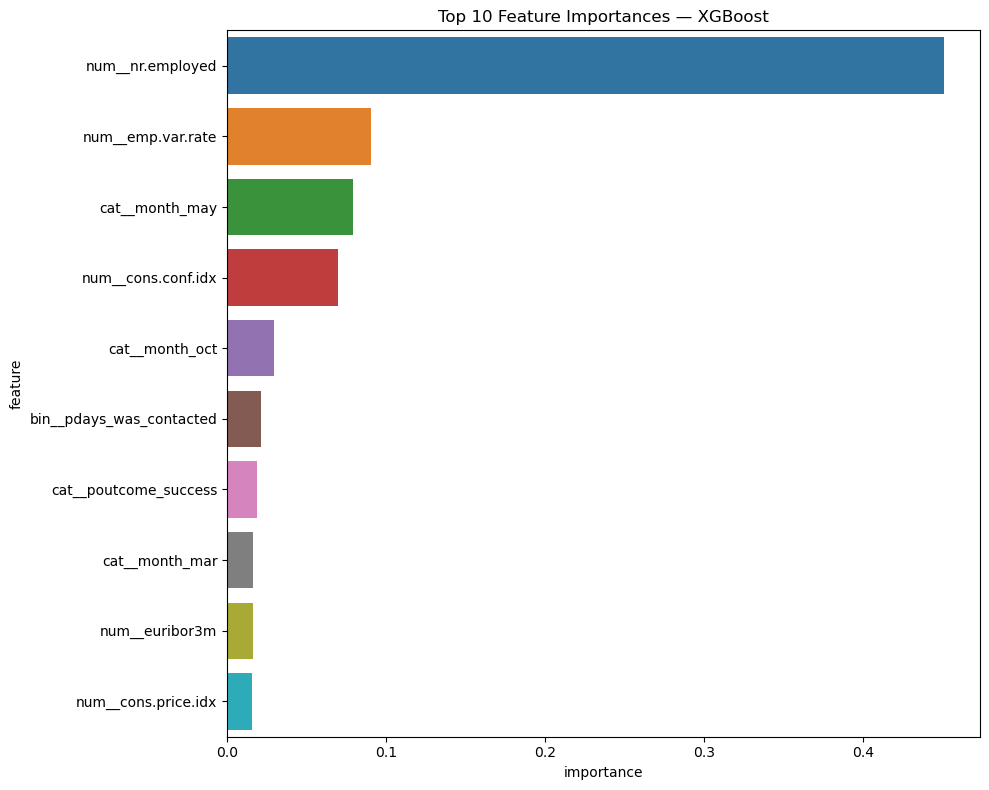

In [68]:
feature_names = preprocessor_noscale.get_feature_names_out()

importances = xgb_random.best_estimator_.feature_importances_
feature_importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance_df.head(10), x="importance", y="feature")
plt.title("Top 10 Feature Importances — XGBoost")
plt.tight_layout()
plt.show()

Найважливішою ознакою виявилась nr.employed з важливістю 0.451, це майже половина 
всієї інформативності моделі. З точки зору common sense 
це логічно: кількість працевлаштованих відображає стан економіки, і коли економіка 
нестабільна люди охочіше обирають депозит як безпечний інструмент збереження коштів.

На другому місці emp.var.rate (0.091) і далі euribor3m (0.016) — теж 
макроекономічні змінні. 

month_may на третьому місці (0.079) теж має сенс, бо у травні була найнижча 
конверсія серед усіх місяців що підтвердилось ще в EDA. Також далі є month_oct, у якому навпаки була найвища конверсія, що теж makes sense.

pdays_was_contacted і poutcome_success присутні хоч і з невисокими значеннями, 
що підтверджує гіпотезу що попередній контакт з клієнтом підвищує шанси на 
підписання депозиту.

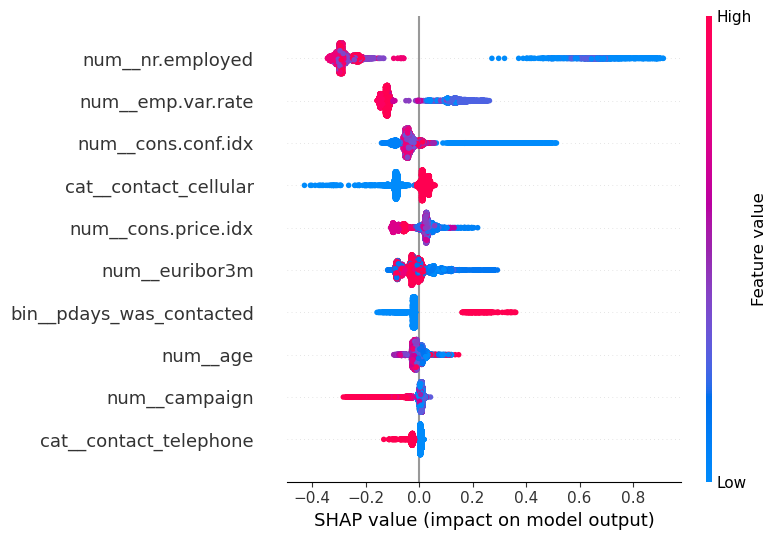

In [69]:
explainer = shap.TreeExplainer(xgb_random.best_estimator_)
shap_values = explainer.shap_values(X_val_noscale)

top10_idx = np.argsort(np.abs(shap_values).mean(axis=0))[::-1][:10]
shap_values_top10 = shap_values[:, top10_idx]
X_val_top10 = X_val_noscale[:, top10_idx]
feature_names_top10 = feature_names[top10_idx]

shap.summary_plot(
    shap_values_top10, 
    X_val_top10, 
    feature_names=feature_names_top10,
    plot_type="dot",
    show=True
)

nr.employed домінує як і в feature importance. Ця змінна має на цільову негативну кореляцію: із ростом її падає  ймовірність підписання депозиту

emp.var.rate і euribor3m показують схожий патерн: низькі значення підвищують 
ймовірність депозиту. Разом з nr.employed це три змінні які відображають один і 
той самий економічний контекст.

cons.conf.idx цікавий тим що низькі значення (синій) дають позитивний SHAP — 
тобто низька довіра споживачів до економіки підвищує шанси на депозит.

pdays_was_contacted показує чіткий розподіл: червоні точки (клієнт був 
контактований раніше) вправо, тобто попередній контакт підвищує ймовірність депозиту, 
що підтверджує гіпотезу з EDA.

campaign навпаки, червоні точки (багато дзвінків) сильно вліво, тобто чим 
більше дзвінків отримав клієнт в цій кампанії тим менша ймовірність що він 
підпише депозит. Теж підтверджує EDA.

contact_cellular і contact_telephone показують протилежні напрямки впливу що 
логічно бо це взаємовиключні категорії після OHE.

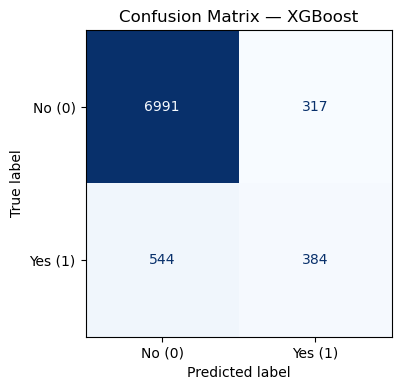

True Positives: 384
True Negatives: 6991
False Positives: 317
False Negatives: 544

False Positives: 317
False Negatives: 544
Correct:7375


In [70]:
best_model = xgb_random.best_estimator_
y_val_proba = best_model.predict_proba(X_val_noscale)[:, 1]
y_val_pred  = (y_val_proba >= best_threshold).astype(int)

cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No (0)", "Yes (1)"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — XGBoost")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positives: {tp}")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")

val_index = X_val_.index
df_val_errors = X_val_.copy()
df_val_errors["y_true"]  = y_val.values
df_val_errors["y_pred"]  = y_val_pred
df_val_errors["proba"]   = y_val_proba

df_val_errors["error_type"] = "correct"
df_val_errors.loc[(df_val_errors["y_true"] == 0) & (df_val_errors["y_pred"] == 1), "error_type"] = "FP"
df_val_errors.loc[(df_val_errors["y_true"] == 1) & (df_val_errors["y_pred"] == 0), "error_type"] = "FN"

fp_df = df_val_errors[df_val_errors["error_type"] == "FP"]
fn_df = df_val_errors[df_val_errors["error_type"] == "FN"]
correct_df = df_val_errors[df_val_errors["error_type"] == "correct"]

print(f"\nFalse Positives: {len(fp_df)}")
print(f"False Negatives: {len(fn_df)}")
print(f"Correct:{len(correct_df)}")

In [71]:
def plot_feature_error(feat):
    fig, ax = plt.subplots(figsize=(10, 4))
    for subset, label, color in [
        (correct_df, "Correct", "steelblue"),
        (fp_df,      "False Positive", "orange"),
        (fn_df,      "False Negative", "red"),
    ]:
        if feat in subset.columns:
            sns.kdeplot(subset[feat], ax=ax, label=label, color=color, fill=True, alpha=0.25)
    ax.set_title(f"Розподіл '{feat}' по типах передбачень")
    ax.set_xlabel(feat)
    ax.legend()
    plt.tight_layout()
    plt.show()

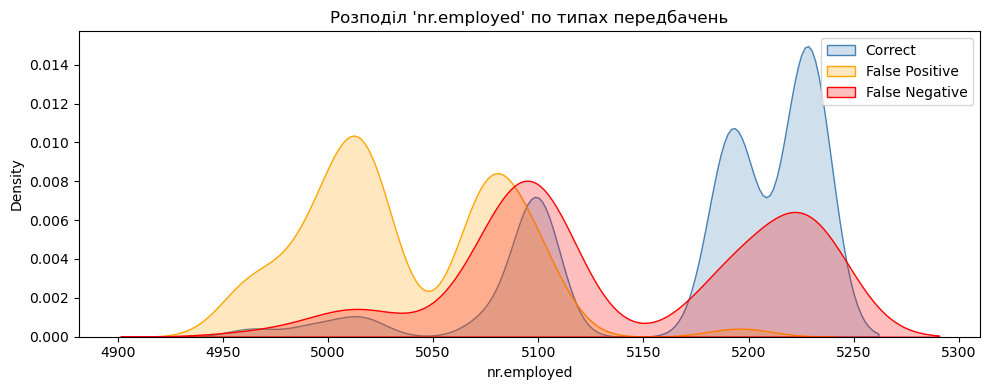

In [72]:
plot_feature_error("nr.employed")

Модель часто сприймала нижчі показники економіки як вищий шанс на підписання депозиту, і навпаки із вищими показниками. 


Середні значення числових ознак по типах передбачень:
error_type            FN        FP   correct
age               39.697    41.874    39.998
campaign           1.071     0.975     1.127
previous           0.215     0.533     0.151
emp.var.rate      -0.690    -2.375     0.252
cons.price.idx    93.296    93.160    93.615
cons.conf.idx    -40.953   -37.588   -40.564
euribor3m          2.802     1.032     3.807
nr.employed     5139.930  5037.449  5175.180


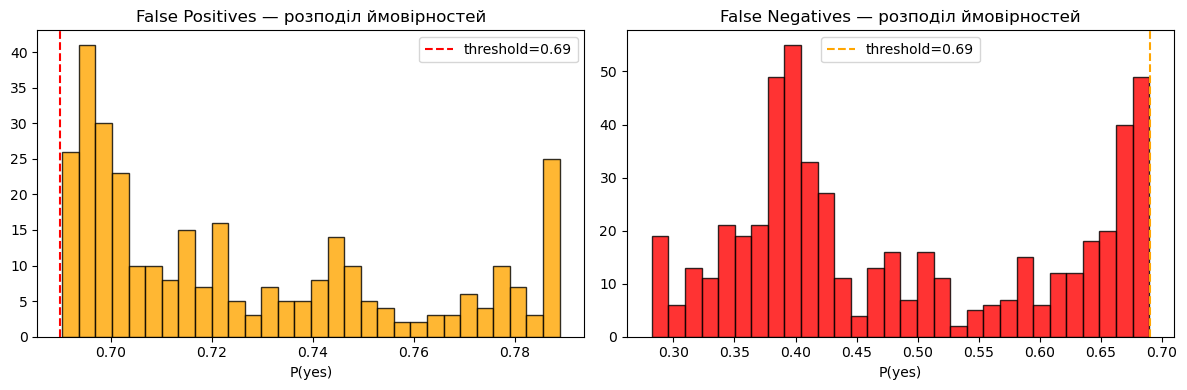


FP: більшість мають proba від 0.69 до 0.79, медіана = 0.72
FN: більшість мають proba від 0.28 до 0.69, медіана = 0.43


In [73]:
num_features_to_check = numeric_cols 
summary = df_val_errors.groupby("error_type")[num_features_to_check].mean().round(3)
print("\nСередні значення числових ознак по типах передбачень:")
print(summary.T.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(fp_df["proba"], bins=30, color="orange", edgecolor="black", alpha=0.8)
axes[0].axvline(best_threshold, color="red", linestyle="--", label=f"threshold={best_threshold:.2f}")
axes[0].set_title("False Positives — розподіл ймовірностей")
axes[0].set_xlabel("P(yes)")
axes[0].legend()

axes[1].hist(fn_df["proba"], bins=30, color="red", edgecolor="black", alpha=0.8)
axes[1].axvline(best_threshold, color="orange", linestyle="--", label=f"threshold={best_threshold:.2f}")
axes[1].set_title("False Negatives — розподіл ймовірностей")
axes[1].set_xlabel("P(yes)")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nFP: більшість мають proba від {fp_df['proba'].min():.2f} до {fp_df['proba'].max():.2f}, медіана = {fp_df['proba'].median():.2f}")
print(f"FN: більшість мають proba від {fn_df['proba'].min():.2f} до {fn_df['proba'].max():.2f}, медіана = {fn_df['proba'].median():.2f}")

In [74]:
cat_features = ["contact", "poutcome", "month", "job", "marital"]

for feat in cat_features:
    if feat in fp_df.columns:
        print(f"\n--- {feat} ---")
        total = df_val_errors.groupby(feat)["error_type"].value_counts(normalize=True).unstack().fillna(0)
        print(total.round(3))


--- contact ---
error_type     FN     FP  correct
contact                          
cellular    0.078  0.059    0.863
telephone   0.045  0.004    0.950

--- poutcome ---
error_type      FN     FP  correct
poutcome                          
failure      0.096  0.059    0.846
nonexistent  0.063  0.028    0.909
success      0.057  0.237    0.706

--- month ---
error_type     FN     FP  correct
month                            
apr         0.135  0.049    0.815
aug         0.074  0.021    0.904
dec         0.081  0.351    0.568
jul         0.062  0.019    0.919
jun         0.047  0.065    0.888
mar         0.123  0.351    0.526
may         0.060  0.004    0.936
nov         0.044  0.035    0.921
oct         0.066  0.353    0.581
sep         0.128  0.239    0.633

--- job ---
error_type        FN     FP  correct
job                                 
admin.         0.066  0.049    0.886
blue-collar    0.056  0.009    0.935
entrepreneur   0.054  0.027    0.919
housemaid      0.025  0.040    0.

False Negatives (модель «пропускає» справжніх клієнтів):
- Макроекономіка: FN мають нижчий nr.employed і нижчий euribor3m . Тобто модель погано розпізнає
   клієнтів які підписують депозит в умовах відносно стабільної
   економіки.
   
- Місяці: найбільша частка FN у квітні і вересні .
  Саме ці місяці мали високу конверсію в EDA, але модель
  все одно недооцінює клієнтів у ці періоди.

- Професії: найбільше FN серед unemployed , student
  і retired. ці групи малочисельні в даних, тому
  модель їх погано вивчила.

- Ймовірності: медіана proba у FN = 0.43, тобто більшість
  розподілені далеко від threshold 0.69. Просте зниження
  threshold частково допоможе, але не вирішить проблему повністю

False Positives (модель «переоцінює» клієнтів, які не підписали):
- Poutcome success: 23.7% FP припадає на клієнтів з успішною
   попередньою кампанією. Модель надто довіряє цій ознаці
   і переоцінює таких клієнтів.

- Місяці: грудень, жовтень і березень
  дають найбільшу частку FP. Це місяці з малою кількістю
  контактів, що означає що модель погано калібрована
  на рідкісних місяцях.

- Професії: найбільше FP серед retired і student. ті самі групи що й у FN, модель загалом нестабільна
  на малих сегментах.

- Ймовірності: медіана proba у FP = 0.72, тобто модель
  досить впевнена у своїх хибних передбаченнях.
  
Загальні ідеї для покращення:
  1. Знизити threshold з 0.69 до ~0.45-0.50 щоб зловити
     більше FN клієнтів.

  2. Додати interaction feature між nr.employed і pdays_was_contacted, щоб модель краще розрізняла клієнтів в стабільній економіці.

  3. Для місяців грудень/жовтень/березень і груп retired/student/unemployed
     зібрати більше даних або застосувати oversampling,
     бо зараз модель нестабільна на малих групах.